In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# set seaborn theme
sns.set_theme()

# initializing variables
REMOVE = '** REMOVE ** 4'

# initialize DataFrame
df_remove = pd.DataFrame(columns=['column'])
df_unknown = pd.DataFrame(columns=['column'])

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 2.3.2
Pandas Version: 2.3.1
Seaborn Version: 0.13.2
Matplotlib Version: 3.10.5
Python Version: 3.11.13


### Import Data

In [2]:
# data file
df = pd.read_pickle("../Data/3aClean_Heart.pkl")

# data label
df_label = pd.read_pickle("../Data/3aClean_Label.pkl")

# don columns
df_don = pd.read_pickle("../Data/3aClean_DON.pkl")

# can columns
df_can = pd.read_pickle("../Data/3aClean_CAN.pkl")

# both columns
df_both = pd.read_pickle("../Data/3aClean_BOTH.pkl")

# nominal columns
df_nominal = pd.read_pickle("../Data/3aClean_Nominal.pkl")

# ordinal columns
df_ordinal = pd.read_pickle("../Data/3aClean_Ordinal.pkl")

# numeric columns
df_numeric = pd.read_pickle("../Data/3aClean_Numeric.pkl")

# object columns
df_object = pd.read_pickle("../Data/3aClean_Object.pkl")

# date columns
df_date = pd.read_pickle("../Data/3aClean_Date.pkl")

# unknown columns
df_unknown = pd.read_pickle("../Data/3aClean_Unknown.pkl")

# drop columns
df_drop = pd.read_pickle("../Data/3aClean_Drop.pkl")

# data dictionary
df_dict = pd.read_pickle("../Data/3aClean_Dictionary.pkl")


# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

#### Data Shape

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Removed Features: {df_drop.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")
print(f"Dictionary Features: {df_dict.shape[0]:,}")

Heart Dataset Rows: 28,751 & Columns: 262
Label Features: 15
Candidate Features: 139
Donor Features: 95
Removed Features: 0
Both Features: 8
Nominal Features: 179
Ordinal Features: 13
Numeric Features: 45
Object Features: 11
Unknown Features: 0
Date Features: 14
Dictionary Features: 302


### Wrangle (Date)

In [4]:
# initialize all date variables
removeCols = uf.definition_search(df_dict, 'date', True)
# NaN counts
NaNDf = uf.percentage_null(df[removeCols])

# list date NaNs
NaNDf

,percentage,NaNCount
ValidationDateTCR_CAN,26.757330,7693
CenterDischargeDate_CAN,2.876422,827
ValidationDateTRR_CAN,1.746026,502
StatusDate_CAN,1.481688,426
AdmissionDate_CAN,1.325171,381
ValidationDateTCR_DDR,0.796494,229
AdmissionDate_DON,0.125213,36
ReferralDate_DON,0.059128,17
OrganRecoveryDate_DON,0.045216,13


#### Remove Features

In [5]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.house_keeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_remove, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 7 row(s) from df_can DataFrame.
Remove 3 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 13 row(s) from df_date DataFrame.

Removed Features: ['AdmissionDate_CAN', 'AdmissionDate_DON', 'AllocationBeginDate_CAN', 'CenterDischargeDate_CAN', 'InitialWaitListDate_CAN', 'OrganRecoveryDate_DON', 'ReferralDate_DON', 'RemovalWaitListDate_CAN', 'StatusDate_CAN', 'TransplantDate_CAN', 'ValidationDateTCR_CAN', 'ValidationDateTCR_DDR', 'ValidationDateTRR_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 28,751 & columns: 262
Total Row(s) & Column(s) After Removing Column(s): 28,751 & columns: 249


### Word Cloud Plot

In [6]:
# import library
from wordcloud import WordCloud

# function to split and clean medications
def split_and_clean(x):
    if pd.isna(x):
        return []
    return [med.strip().upper() for med in str(x).split(',')]


def wordFreqPlot(data, txt, flag=True, filename="../Image/WordCloud.png", dpi=1200):
    """
    Word Cloud Plot combine multiple Text Features
    """
    # combine the columns
    data['CombinedMeds'] = data[txt].apply(lambda row: 
        list(sum([split_and_clean(cell) for cell in row if pd.notna(cell)], [])), axis=1)
    
    # convert the list to a comma-separated string
    data['CombinedMeds'] = data['CombinedMeds'].apply(lambda x: ', '.join(sorted(x)) if x else None)

    #
    if flag:
        # combine all medications into a single string
        text = ' '.join(df['CombinedMeds'].dropna().astype(str))
        
        # preprocess text: Convert to upper case and remove duplicates
        text = ' '.join(set(word.upper() for word in text.split(',')))
    
        # Create and generate a word cloud image
        wordcloud = WordCloud(width=1200, height=800, background_color='white').generate(text)
        
        # display the generated image
        plt.figure(figsize=(16, 8))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Combine {len(txt)} Text Columns **{txt}** Word Cloud \n", fontsize=12)
        plt.tight_layout(pad=0)
                # Save the figure if a filename is provided
        plt.show()
        if filename:
            plt.savefig(filename, dpi=dpi, bbox_inches='tight') # Use plt.savefig to control DPI
            print(f"Word cloud saved to {filename} with DPI {dpi}")
            wordcloud.to_file(filename)
            print(f"Word cloud saved to {filename}")
    else:
        return  data['CombinedMeds']

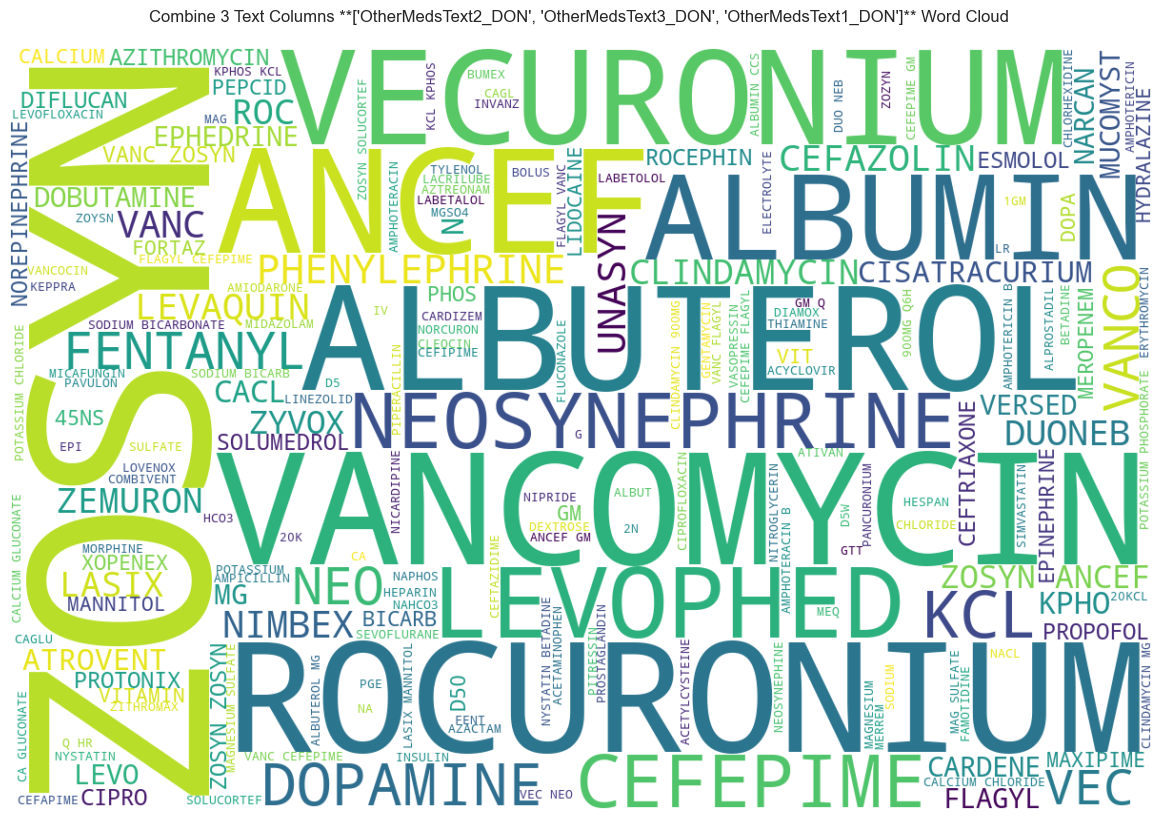

Word cloud saved to ../Image/WordCloud.png with DPI 1200
Word cloud saved to ../Image/WordCloud.png


<Figure size 640x480 with 0 Axes>

In [7]:
# initialize list
txtCol = ['OtherMedsText2_DON', 'OtherMedsText3_DON', 'OtherMedsText1_DON']
# plot
wordFreqPlot(df, txtCol, flag=True)

**Note:**
- **ZOSYN** (piperacillin and tazobactam for injection, USP) is an injectable antibacterial combination product consisting of the semisynthetic antibiotic piperacillin sodium and the β‑lactamase inhibitor tazobactam sodium for intravenous administration. Piperacillin sodium is derived from D(-)-α-aminobenzyl-penicillin.
- **Rocuronium** is a non-depolarizing neuromuscular blocker widely used to produce muscle relaxation to help facilitate surgery and ventilation of the lungs in elective and emergent situations.
- **Vancomycin** is a tricyclic glycopeptide antibiotic originally derived from the organism Streptococcus orientalis. Vancomycin is used to treat and prevent various bacterial infections caused by gram-positive bacteria, including methicillin-resistant Staphylococcus aureus (MRSA).
- **Vecuronium** is a nondepolarizing agent that achieves skeletal muscle paralysis by competing with acetylcholine for cholinergic receptor sites and binding with the nicotinic cholinergic receptor at the postjunctional membrane of the motor endplate.
- **Albuterol** is used to prevent and treat difficulty breathing, wheezing, shortness of breath, coughing, and chest tightness caused by lung diseases such as asthma and chronic obstructive pulmonary disease (COPD; a group of diseases that affect the lungs and airways).

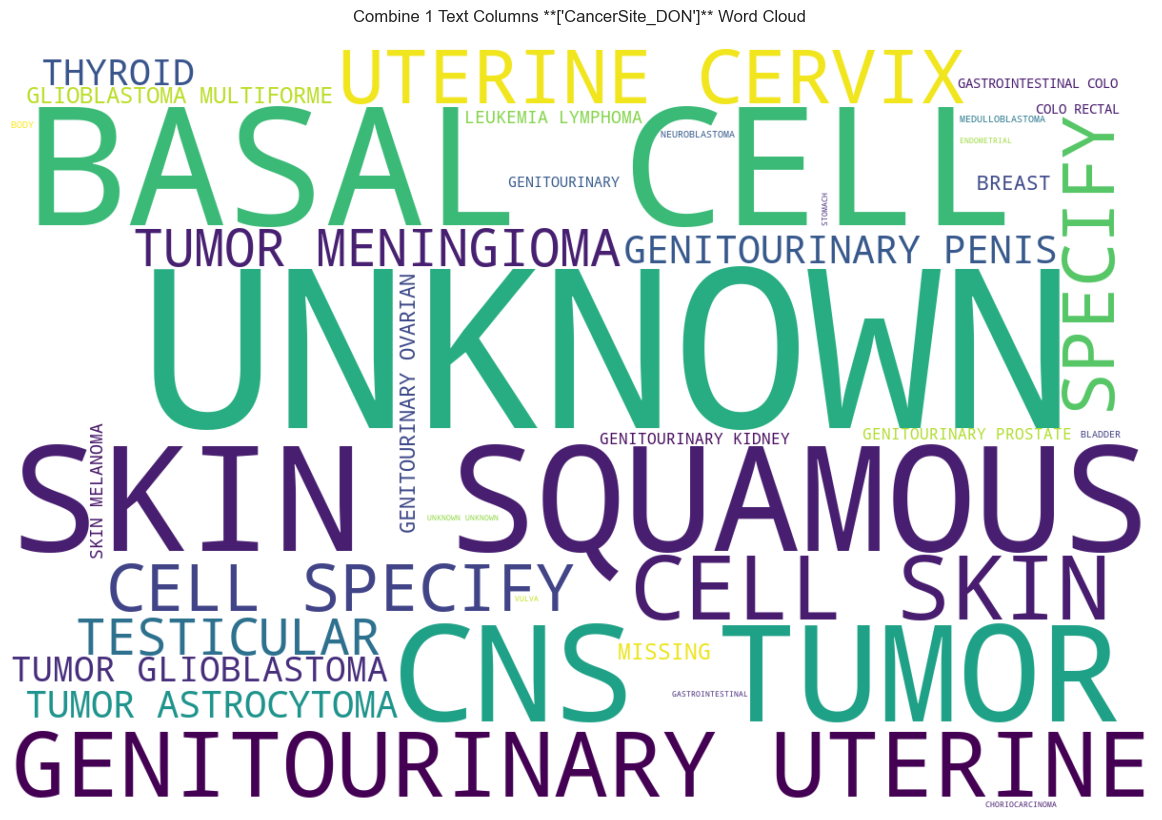

Word cloud saved to ../Image/WordCloud.png with DPI 1200
Word cloud saved to ../Image/WordCloud.png


<Figure size 640x480 with 0 Axes>

In [8]:
# initialize list
txtCol = ['CancerSite_DON']
# plot
wordFreqPlot(df, txtCol, flag=True)

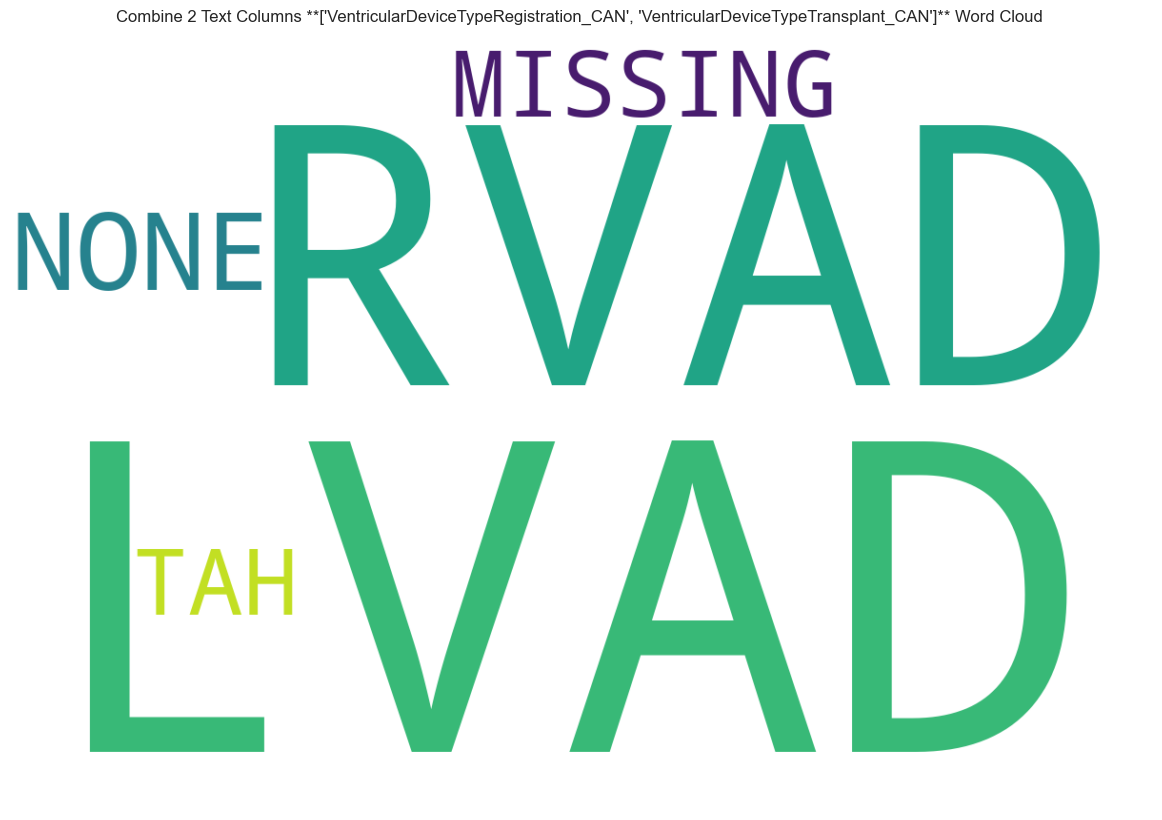

Word cloud saved to ../Image/WordCloud.png with DPI 1200
Word cloud saved to ../Image/WordCloud.png


<Figure size 640x480 with 0 Axes>

In [9]:
# initialize list
txtCol = ['VentricularDeviceTypeRegistration_CAN', 'VentricularDeviceTypeTransplant_CAN']
# plot
wordFreqPlot(df, txtCol, flag=True)

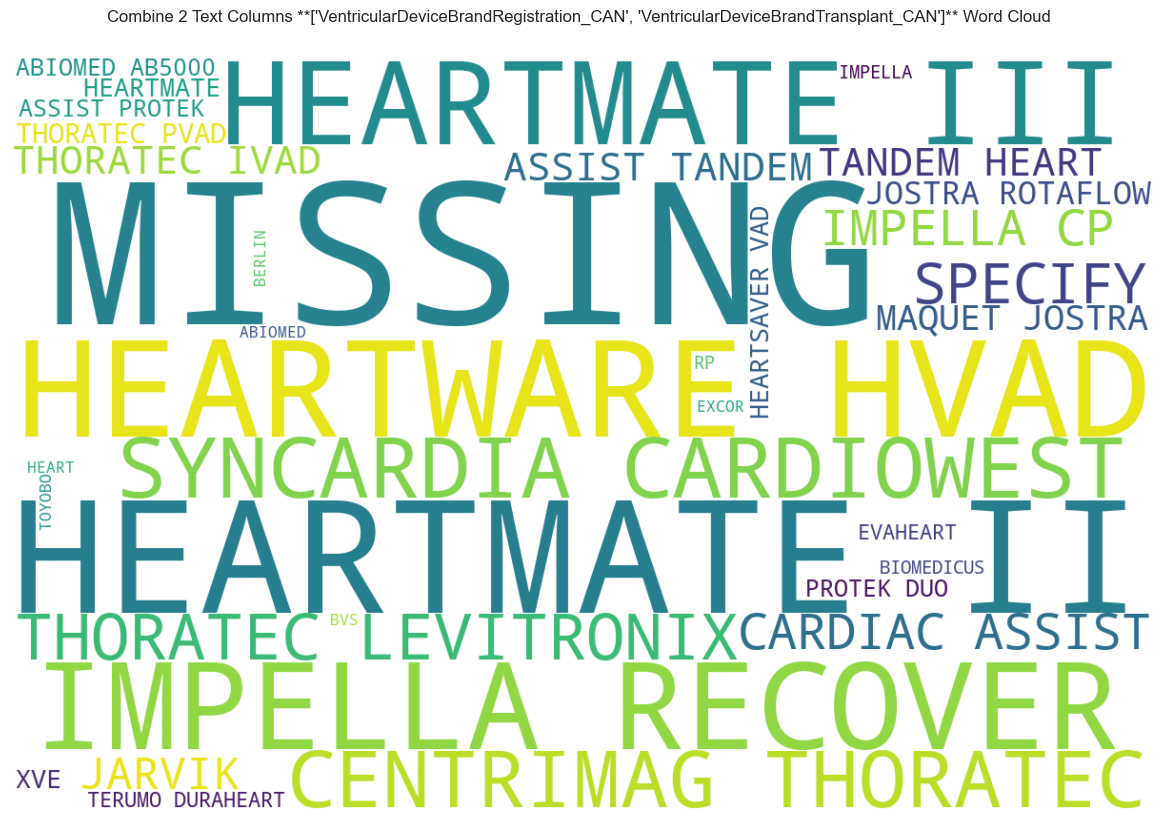

Word cloud saved to ../Image/WordCloud.png with DPI 1200
Word cloud saved to ../Image/WordCloud.png


<Figure size 640x480 with 0 Axes>

In [10]:
# initialize list
txtCol = ['VentricularDeviceBrandRegistration_CAN', 'VentricularDeviceBrandTransplant_CAN']
# plot
wordFreqPlot(df, txtCol, flag=True)

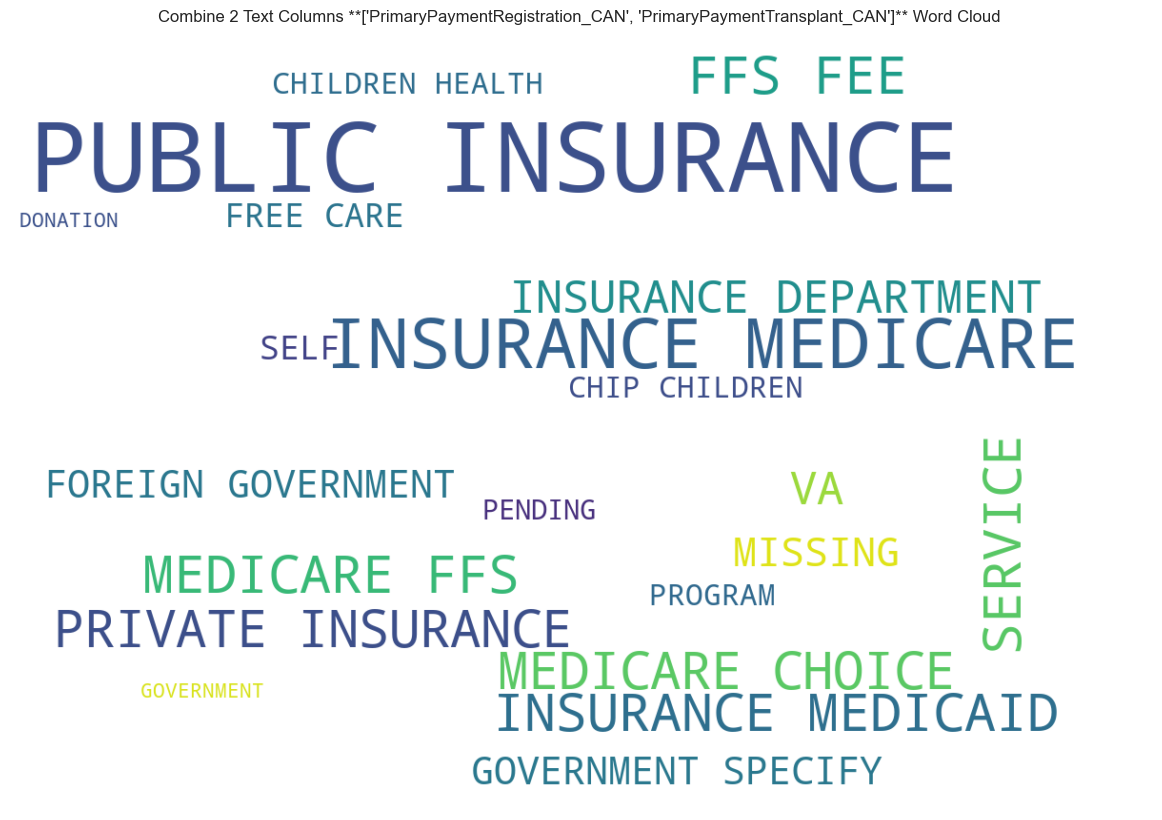

Word cloud saved to ../Image/WordCloud.png with DPI 1200
Word cloud saved to ../Image/WordCloud.png


<Figure size 640x480 with 0 Axes>

In [11]:
# initialize list
txtCol = ['PrimaryPaymentRegistration_CAN', 'PrimaryPaymentTransplant_CAN']
# plot
wordFreqPlot(df, txtCol, flag=True)

In [12]:
# display head
df[df_object.column.to_list()].head()

,VentricularDeviceTypeRegistration_CAN,VentricularDeviceTypeTransplant_CAN,VentricularDeviceBrandRegistration_CAN,VentricularDeviceBrandTransplant_CAN,PrimaryPaymentRegistration_CAN,PrimaryPaymentTransplant_CAN,DialysisTypeRegistration_CAN,CancerSite_DON,OtherMedsText1_DON,OtherMedsText2_DON,OtherMedsText3_DON
0,Lvad+Rvad,Lvad+Rvad,CentriMag (Thoratec/Levitronix),CentriMag (Thoratec/Levitronix),Public insurance - Medicaid,Public insurance - Medicaid,No dialysis,NO,"ZOSYN, VANCOMYCIN","KCL,","DOPAMINE, VASOPRESSIN,"
1,Lvad,Lvad,Heartmate II,Heartmate II,Public insurance - Medicare FFS (Fee for Service),Public insurance - Medicare FFS (Fee for Service),No dialysis,NO,"ANCEF, FENTANYL, VERSED,LASIX",NaN,NaN
2,None,None,Missing,Missing,Private insurance,Private insurance,No dialysis,NO,"ZOSYN, VANCOMYCIN","AMPHOTERICIN, BETADINE",ZANTAC
3,Lvad+Rvad,Lvad,CentriMag (Thoratec/Levitronix),Heartmate II,Public insurance - Medicare & Choice,Private insurance,No dialysis,"SKIN - SQUAMOUS, BASAL CELL","KCL, VANCO, MAG, ZOSYN","D50, DOPAMINE, DIFLUCAN",NaN
4,Lvad,Lvad,Heartmate II,Heartmate II,Public insurance - Medicare & Choice,Public insurance - Medicare & Choice,No dialysis,NO,"ROCURONIUM, VECURONIUM","ZOSYN, CIPROFLOXACIN","BUMETIDE, ANCEF"


In [13]:
# add new text feature to be removed
removeCols = df_object.column.to_list()

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.house_keeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_remove, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 6 row(s) from df_can DataFrame.
Remove 4 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 11 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['CancerSite_DON', 'DialysisTypeRegistration_CAN', 'OtherMedsText1_DON', 'OtherMedsText2_DON', 'OtherMedsText3_DON', 'PrimaryPaymentRegistration_CAN', 'PrimaryPaymentTransplant_CAN', 'VentricularDeviceBrandRegistration_CAN', 'VentricularDeviceBrandTransplant_CAN', 'VentricularDeviceTypeRegistration_CAN', 'VentricularDeviceTypeTransplant_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 28,751 & columns: 250
Total Row(s) & Column(s) After Removing Column(s): 28,751 & columns: 239


### Examine NaN columns

In [14]:
# NaN counts
NaNDf = uf.percentage_null(df)

# remove feature(s) with over 40% NaNs
removeCols = NaNDf[NaNDf.percentage >= 40].index.values

# dispaly
NaNDf[NaNDf.percentage >= 40]

,percentage,NaNCount
PriorCardiacSurgeryTypeText_CAN,79.134639,22752
Class2PRA_TransplantPercentage_CAN,72.220097,20764
Class1PRA_TransplantPercentage_CAN,71.680985,20609
TotalSerumAlbuminRegistration_CAN,70.738409,20338
CPRA_Peak_CAN,46.050572,13240
CPRA_Recent_CAN,46.008834,13228


#### Remove Features

In [15]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.house_keeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_remove, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 6 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 1 row(s) from df_nominal DataFrame.
Remove 5 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['CPRA_Peak_CAN', 'CPRA_Recent_CAN', 'Class1PRA_TransplantPercentage_CAN', 'Class2PRA_TransplantPercentage_CAN', 'PriorCardiacSurgeryTypeText_CAN', 'TotalSerumAlbuminRegistration_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 28,751 & columns: 239
Total Row(s) & Column(s) After Removing Column(s): 28,751 & columns: 233


In [16]:
# correlation
usf.correlation_with_threshold(df[df_numeric.column.to_list()], method='pearson', threshold=0.9)

Correlation between GraftLifeSpanDay and TransplantSurvivalDay: 0.999
Correlation between Age_CAN and Age_Listing_CAN: 0.996
Correlation between HemodynamicsTransplant_PA_DIA_CAN and HemodynamicsTransplant_PA_MN_CAN: 0.901
Correlation between HemodynamicsRegistration_PA_MN_CAN and HemodynamicsRegistration_SYS_CAN: 0.919
Correlation between HemodynamicsTransplant_PA_MN_CAN and HemodynamicsTransplant_SYS_CAN: 0.917


#### Univariate Plots 

In [17]:
# initialize list
labelCol = df_label.column.to_list()
# join to concatenate the strings with '|' separator
labelSearch = '|'.join(labelCol)
# display search
uf.definition_search(df_dict, labelSearch)

,Feature,Description,DataType,SASAnalysisFormat,Comment,FeatureType,Information
4,AcuteRejectionEpisode,DID RECIPIENT HAVE ANY ACUTE REJECTION EPISODES PRE DISCHARGE?,NUM,REJEPIKI,,Category,** LABEL ** FMTNAME: REJEPIKI
109,FunctionalStatusFollowUp,TRF FUNCTIONAL STATUS @ TRR/FOL,NUM,FUNCSTAT,,Category,FMTNAME: FUNCSTAT
113,GraftStatus,GRAFT STATUS,CHAR(1),GRFSTAT,,Category,** LABEL ** N/Y/U/X to No/Yes/Unknown/Missing
114,GraftFailStatus,GRAFT FAILED (1=YES),NUM,,,Category,** LABEL **
115,GraftLifeSpanDay,GRAFT LIFESPAN-Days From Transplant to Failure/Death/Last Follow-Up,NUM,,,Numeric,** LABEL **
189,LastFollowupNumber,LAST FOLLOWUP NUMBER,NUM,,,Numeric,** LABEL **
193,LengthOfStay,RECIPIENT LENGTH OF STAY POST TX,NUM,,,Numeric,** LABEL ** N/Y/U/X to No/Yes/Unknown/Missing
234,AirwayDehiscencePostTransplant,EVENTS PRIOR TO DISCHARGE: AIRWAY DEHISCENCE,CHAR(1),,,Category,** LABEL ** N/Y/U/X to No/Yes/Unknow/Missing
235,DialysisPostDischarge,EVENTS PRIOR TO DISCHARGE: DIALYSIS,CHAR(1),,,Category,** LABEL ** N/Y/U/X to No/Yes/Unknow/Missing
236,PacemakerPostTransplant,EVENTS PRIOR TO DISCHARGE: PERMANENT PACEMAKER,CHAR(1),,,Category,** LABEL ** N/Y/U/X to No/Yes/Unknow/Missing


In [18]:
def plot_categorical_feature_count(data, feature_cat, txt='', fig_size=(25, 15), tick_font=13, title_font=12, x_rotation=0):
    """
    Create count plots for multiple categorical features with count totals displayed at the top of each bar.
    """
    num_features = len(feature_cat)
    cols = 2
    rows = (num_features + cols - 1) // cols

    plt.figure(figsize=fig_size)

    for i, feature in enumerate(feature_cat, start=1):
        ax = plt.subplot(rows, cols, i)
        sns.countplot(data=data, x=feature, hue=feature, palette='Set2', legend=False, ax=ax)
        # plt.title(f'\n{feature} {txt}', fontsize=title_font)
        plt.xlabel(feature, fontsize=tick_font, fontweight='bold')
        plt.ylabel("Frequency", fontsize=tick_font, fontweight='bold')
        plt.xticks(fontsize=tick_font, rotation=x_rotation)
        plt.yticks(fontsize=tick_font)

        # Annotate bars with counts
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{int(height):,}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        fontsize=tick_font, fontweight='bold', color='black', 
                        xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

def category_contingency(data, group, label, observed=False, fill_value=0):
    """
    This function creates a contingency table for analyzing the frequency distribution 
    of a categorical label across different groups. It also calculates row-wise percentages
    for 'Dead' and 'Living' per category, including totals for the last row.
    """
    # Create contingency table
    data = data.groupby(group, observed=observed)[label].value_counts().unstack(fill_value=fill_value)
    
    # Get index name
    indexName = data.index.name
    
    # Add row totals
    data['Row Total'] = data.sum(axis=1)
    
    # Calculate row-wise percentages
    if 'Failure' in data.columns:
        data['Dead %'] = (data['Failure'] / data['Row Total']) * 100
    else:
        data['Dead %'] = 0

    if 'Success' in data.columns:
        data['Living %'] = (data['Success'] / data['Row Total']) * 100
    else:
        data['Living %'] = 0
    
    # Add column totals
    totals = data.sum().to_frame().T
    totals.index = ['Column Total']
    
    # Ensure percentages and totals for 'Living' and 'Dead' are correct
    totals['Dead %'] = (totals['Failure'] / totals['Row Total']) * 100 if 'Failure' in totals.columns else 0
    totals['Living %'] = (totals['Success'] / totals['Row Total']) * 100 if 'Success' in totals.columns else 0
    
    # Concatenate the totals row to the original DataFrame
    df_with_totals = pd.concat([data, totals])
    
    # Set index name
    df_with_totals.index.name = indexName
    
    return df_with_totals

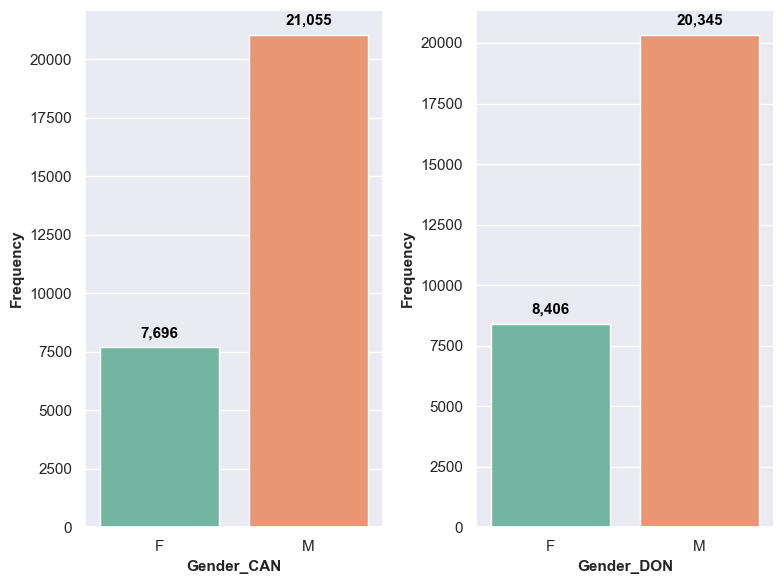

In [19]:
plot_categorical_feature_count(df, ['Gender_CAN', 'Gender_DON'], fig_size=(8, 6), tick_font=11, title_font=10)

In [20]:
df['Gender_CAN'].value_counts(normalize=True)

Gender_CAN
M    0.732322
F    0.267678
Name: proportion, dtype: float64

In [21]:
df['Gender_DON'].value_counts(normalize=True)

Gender_DON
M    0.707628
F    0.292372
Name: proportion, dtype: float64

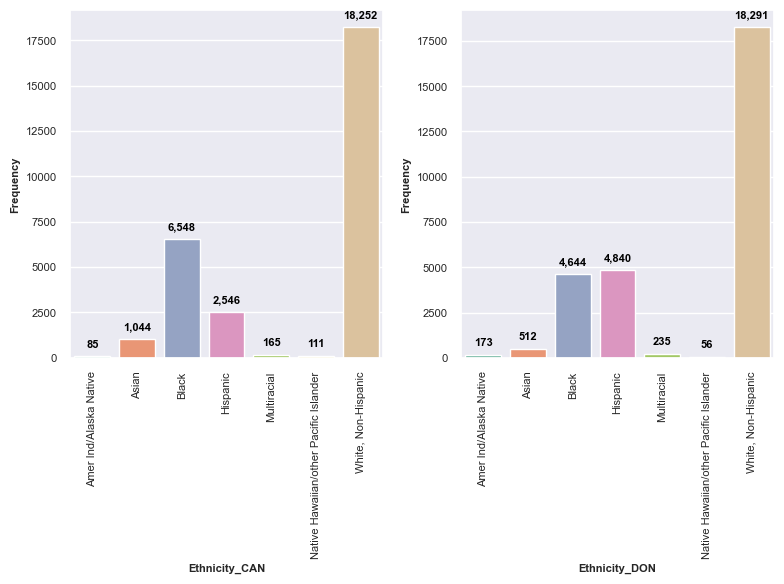

In [22]:
plot_categorical_feature_count(df, ['Ethnicity_CAN', 'Ethnicity_DON'], fig_size=(8, 6), tick_font=8, title_font=10, x_rotation=90)

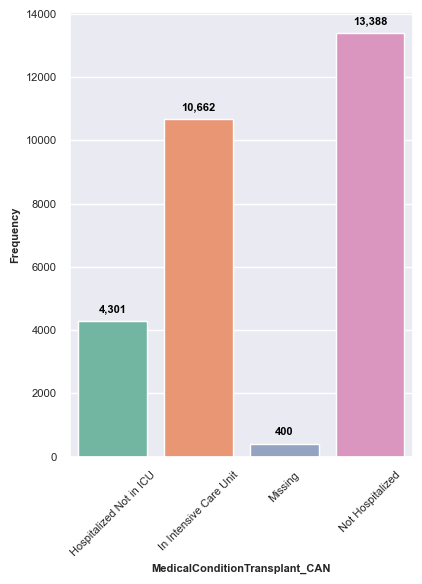

In [23]:
plot_categorical_feature_count(df, ['MedicalConditionTransplant_CAN'], fig_size=(8, 6), tick_font=8, title_font=10, x_rotation=45)

In [24]:
category_contingency(df, 'MedicalConditionTransplant_CAN', 'GraftFailStatus')

GraftFailStatus,Failure,Missing,Success,Row Total,Dead %,Living %
MedicalConditionTransplant_CAN,,,,,,
Hospitalized Not in ICU,887.0,7.0,3407.0,4301.0,20.623111,79.214136
In Intensive Care Unit,2009.0,37.0,8616.0,10662.0,18.842619,80.810355
Missing,4.0,356.0,40.0,400.0,1.000000,10.000000
Not Hospitalized,2846.0,26.0,10516.0,13388.0,21.257843,78.547953
Column Total,5746.0,426.0,22579.0,28751.0,19.985392,78.532921


In [25]:
df['MedicalConditionTransplant_CAN'].value_counts(normalize=True)

MedicalConditionTransplant_CAN
Not Hospitalized           0.465653
In Intensive Care Unit     0.370839
Hospitalized Not in ICU    0.149595
Missing                    0.013913
Name: proportion, dtype: float64

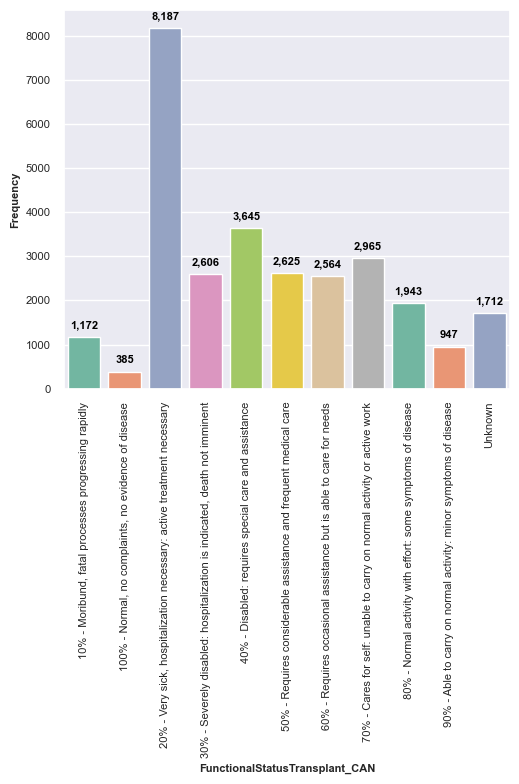

In [26]:
plot_categorical_feature_count(df, ['FunctionalStatusTransplant_CAN'], fig_size=(10, 8), tick_font=8, title_font=10, x_rotation=90)

In [27]:
category_contingency(df, 'FunctionalStatusTransplant_CAN', 'GraftFailStatus')

GraftFailStatus,Failure,Missing,Success,Row Total,Dead %,Living %
FunctionalStatusTransplant_CAN,,,,,,
"10% - Moribund, fatal processes progressing rapidly",257.0,8.0,907.0,1172.0,21.928328,77.389078
"100% - Normal, no complaints, no evidence of disease",84.0,0.0,301.0,385.0,21.818182,78.181818
"20% - Very sick, hospitalization necessary: active treatment necessary",1578.0,23.0,6586.0,8187.0,19.274460,80.444607
"30% - Severely disabled: hospitalization is indicated, death not imminent",507.0,4.0,2095.0,2606.0,19.455104,80.391404
40% - Disabled: requires special care and assistance,758.0,12.0,2875.0,3645.0,20.795610,78.875171
50% - Requires considerable assistance and frequent medical care,543.0,12.0,2070.0,2625.0,20.685714,78.857143
60% - Requires occasional assistance but is able to care for needs,518.0,2.0,2044.0,2564.0,20.202808,79.719189
70% - Cares for self: unable to carry on normal activity or active work,651.0,2.0,2312.0,2965.0,21.956155,77.976391
80% - Normal activity with effort: some symptoms of disease,396.0,1.0,1546.0,1943.0,20.380854,79.567679


In [28]:
import dataframe_image as dfi

# contingency table
contingency_table = category_contingency(df, 'PrimaryDiagnosisType_CAN', 'GraftFailStatus')

# Save as PNGa
dfi.export(contingency_table, 'contingency_table.png', table_conversion='matplotlib')

In [29]:
!pwd

/Users/sir/Desktop/Project/UNOS/Notebook


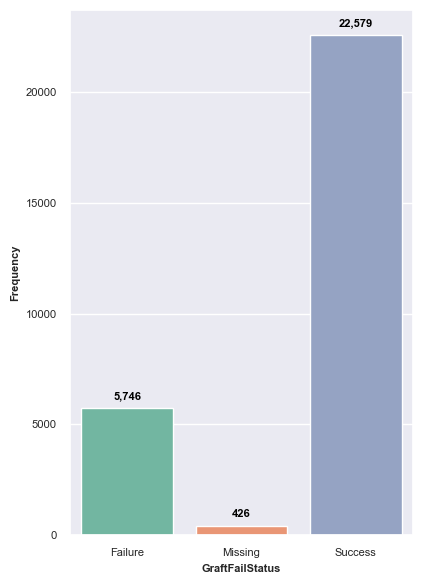

In [30]:
plot_categorical_feature_count(df, ['GraftFailStatus'], fig_size=(8, 6), tick_font=8, title_font=10, x_rotation=0)

In [31]:
df['GraftFailStatus'].value_counts(normalize=True)

GraftFailStatus
Success    0.785329
Failure    0.199854
Missing    0.014817
Name: proportion, dtype: float64

#### Label Plots

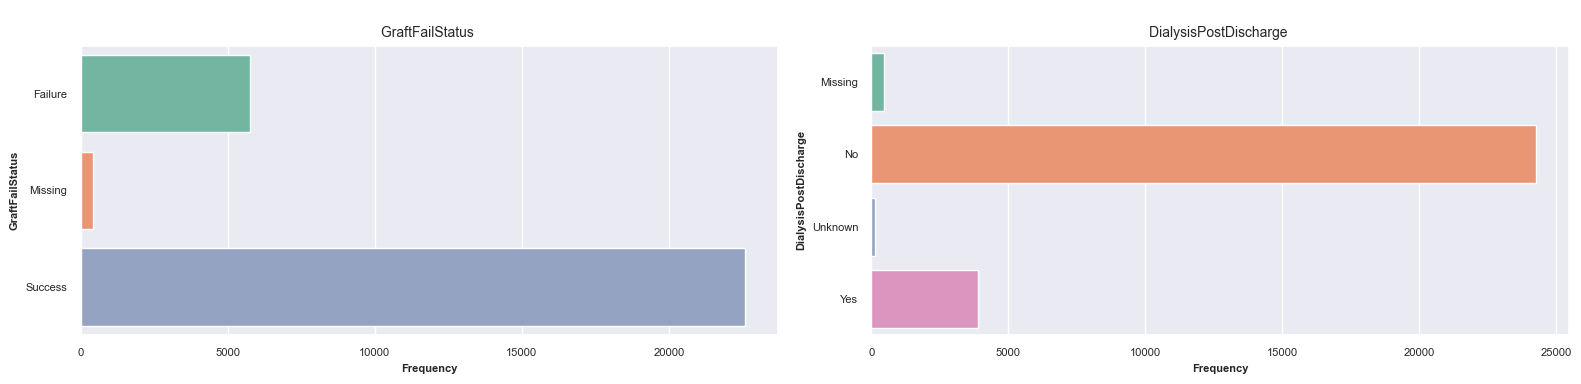

In [32]:
uv.plot_categorical_feature_count(df, ['GraftFailStatus', 'DialysisPostDischarge'], fig_size=(16, 4), tick_font=8, title_font=10)

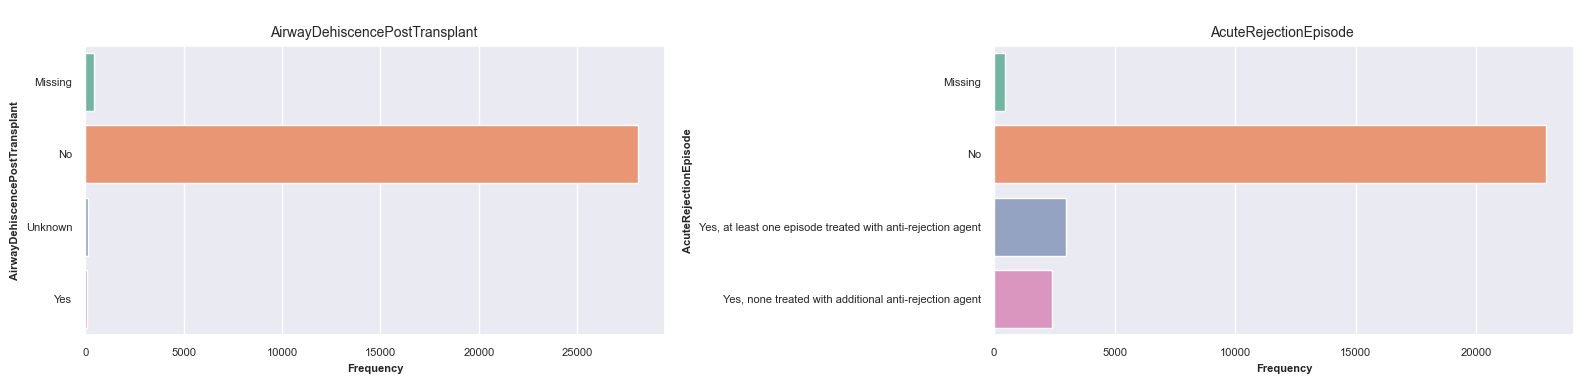

In [33]:
uv.plot_categorical_feature_count(df, ['AirwayDehiscencePostTransplant', 'AcuteRejectionEpisode'], fig_size=(16, 4), tick_font=8, title_font=10)

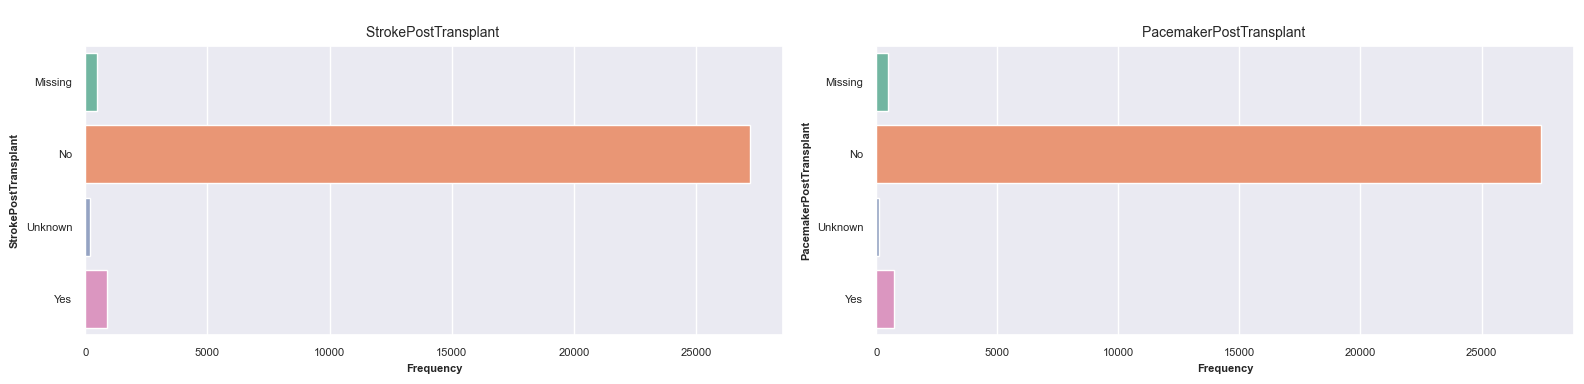

In [34]:
uv.plot_categorical_feature_count(df, ['StrokePostTransplant', 'PacemakerPostTransplant'], fig_size=(16, 4), tick_font=8, title_font=10)

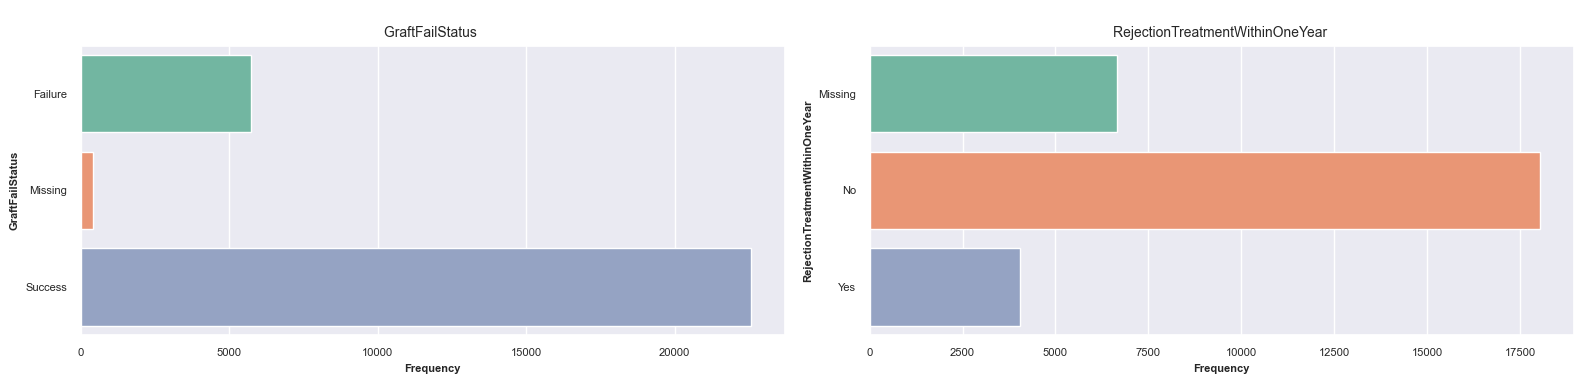

In [35]:
uv.plot_categorical_feature_count(df, ['GraftFailStatus', 'RejectionTreatmentWithinOneYear'], fig_size=(16, 4), tick_font=8, title_font=10)

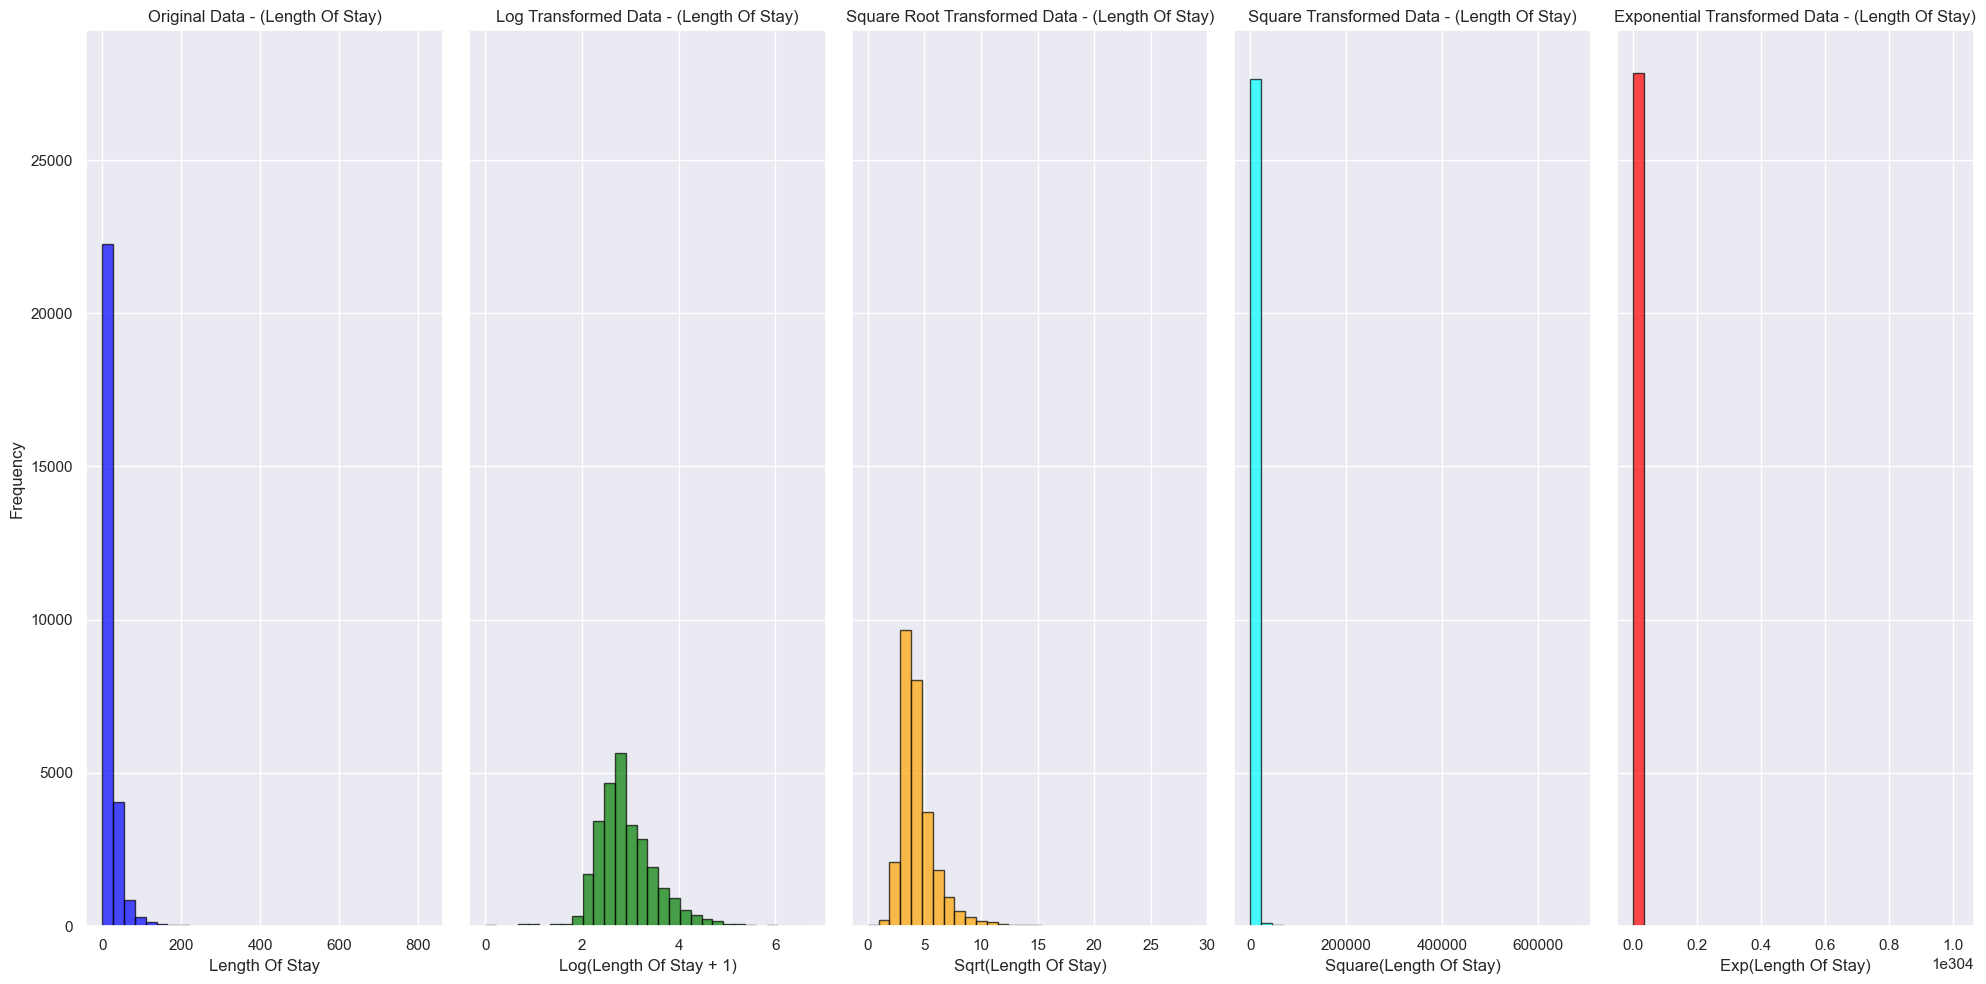

In [36]:
# histogram plots
uv.plot_transform_distribution(df.LengthOfStay, txt='Length Of Stay')

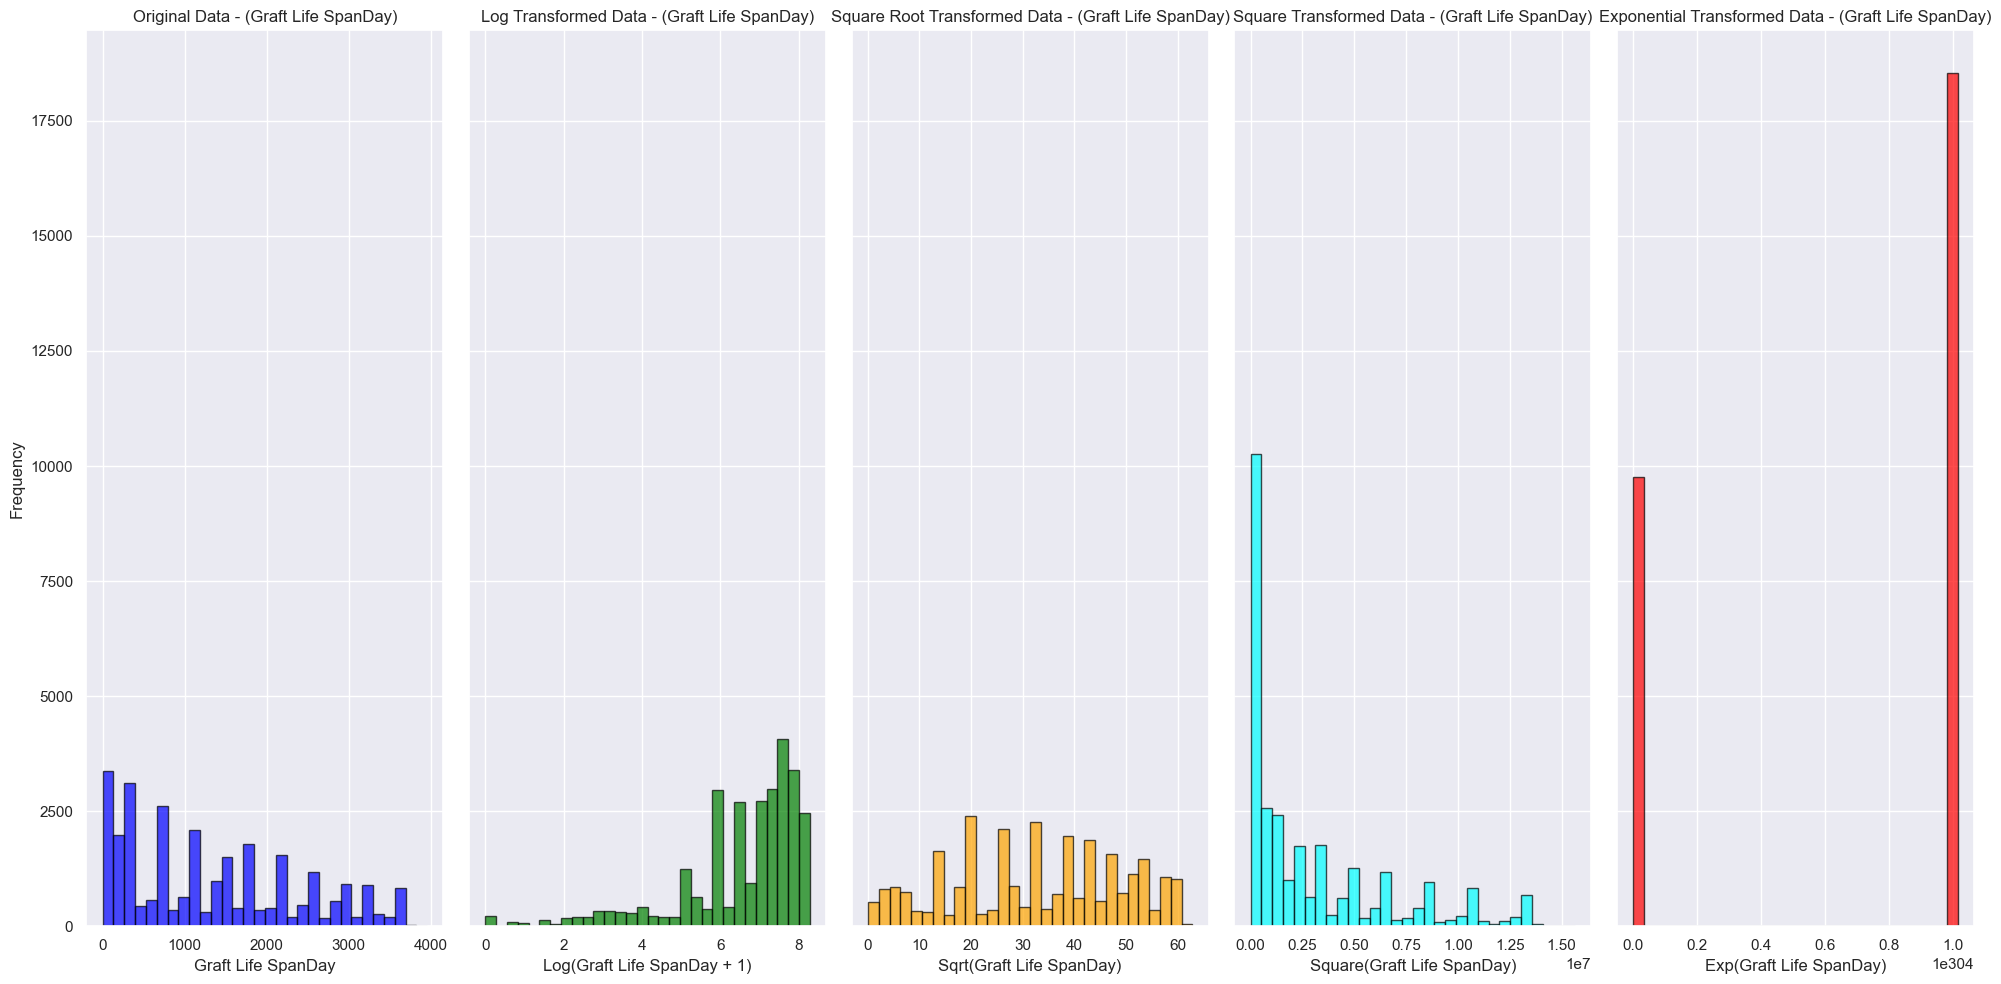

In [37]:
# histogram plots
uv.plot_transform_distribution(df.GraftLifeSpanDay, txt='Graft Life SpanDay')

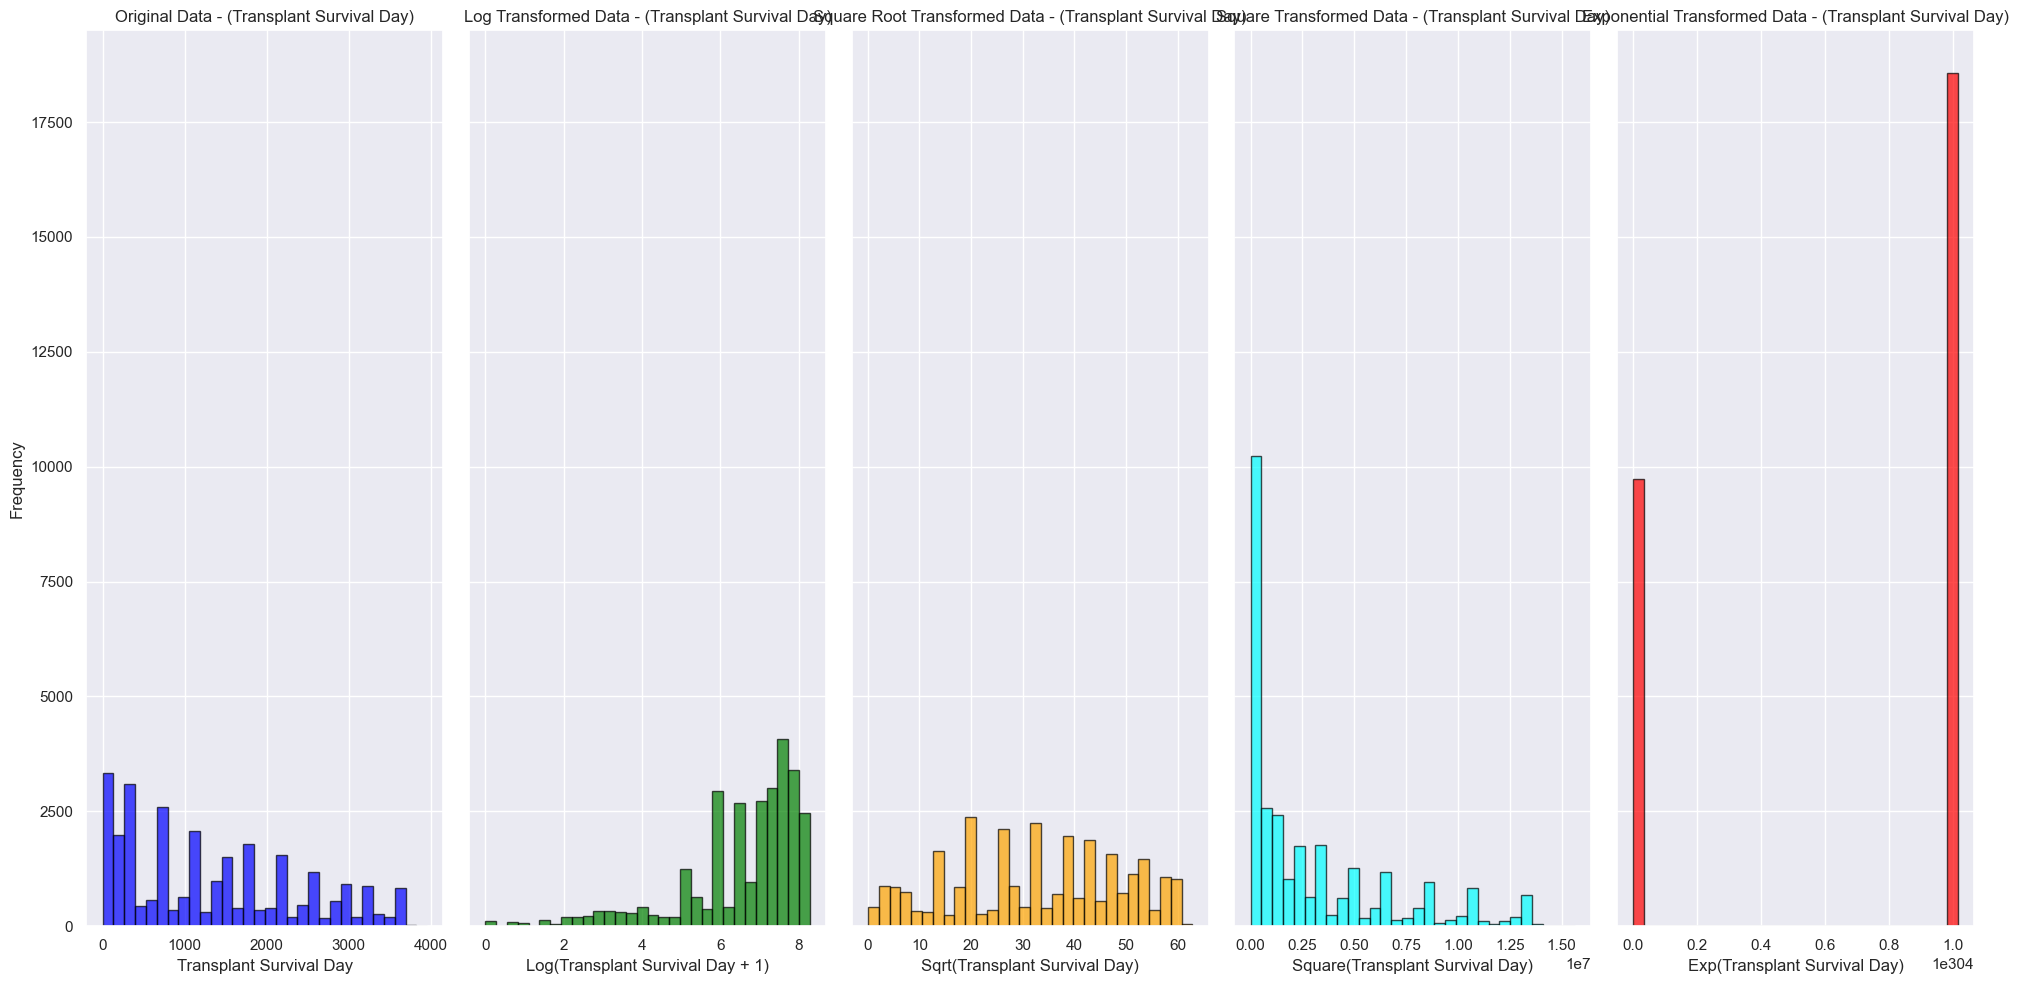

In [38]:
# histogram plots
uv.plot_transform_distribution(df.TransplantSurvivalDay, txt='Transplant Survival Day')

#### Object Datatype

In [39]:
# remove column
df = uf.remove_column(df, ['CombinedMeds'])


Removed Features: ['CombinedMeds']

Total Row(s) & Column(s) Before Removing Column(s): 28,751 & columns: 233
Total Row(s) & Column(s) After Removing Column(s): 28,751 & columns: 232


#### Categorical Features

In [40]:
import random

# all nominal features
catplot = (sorted(df_nominal.column.to_list()))

# random 20
random.shuffle(catplot)
random_sample = catplot[:20]

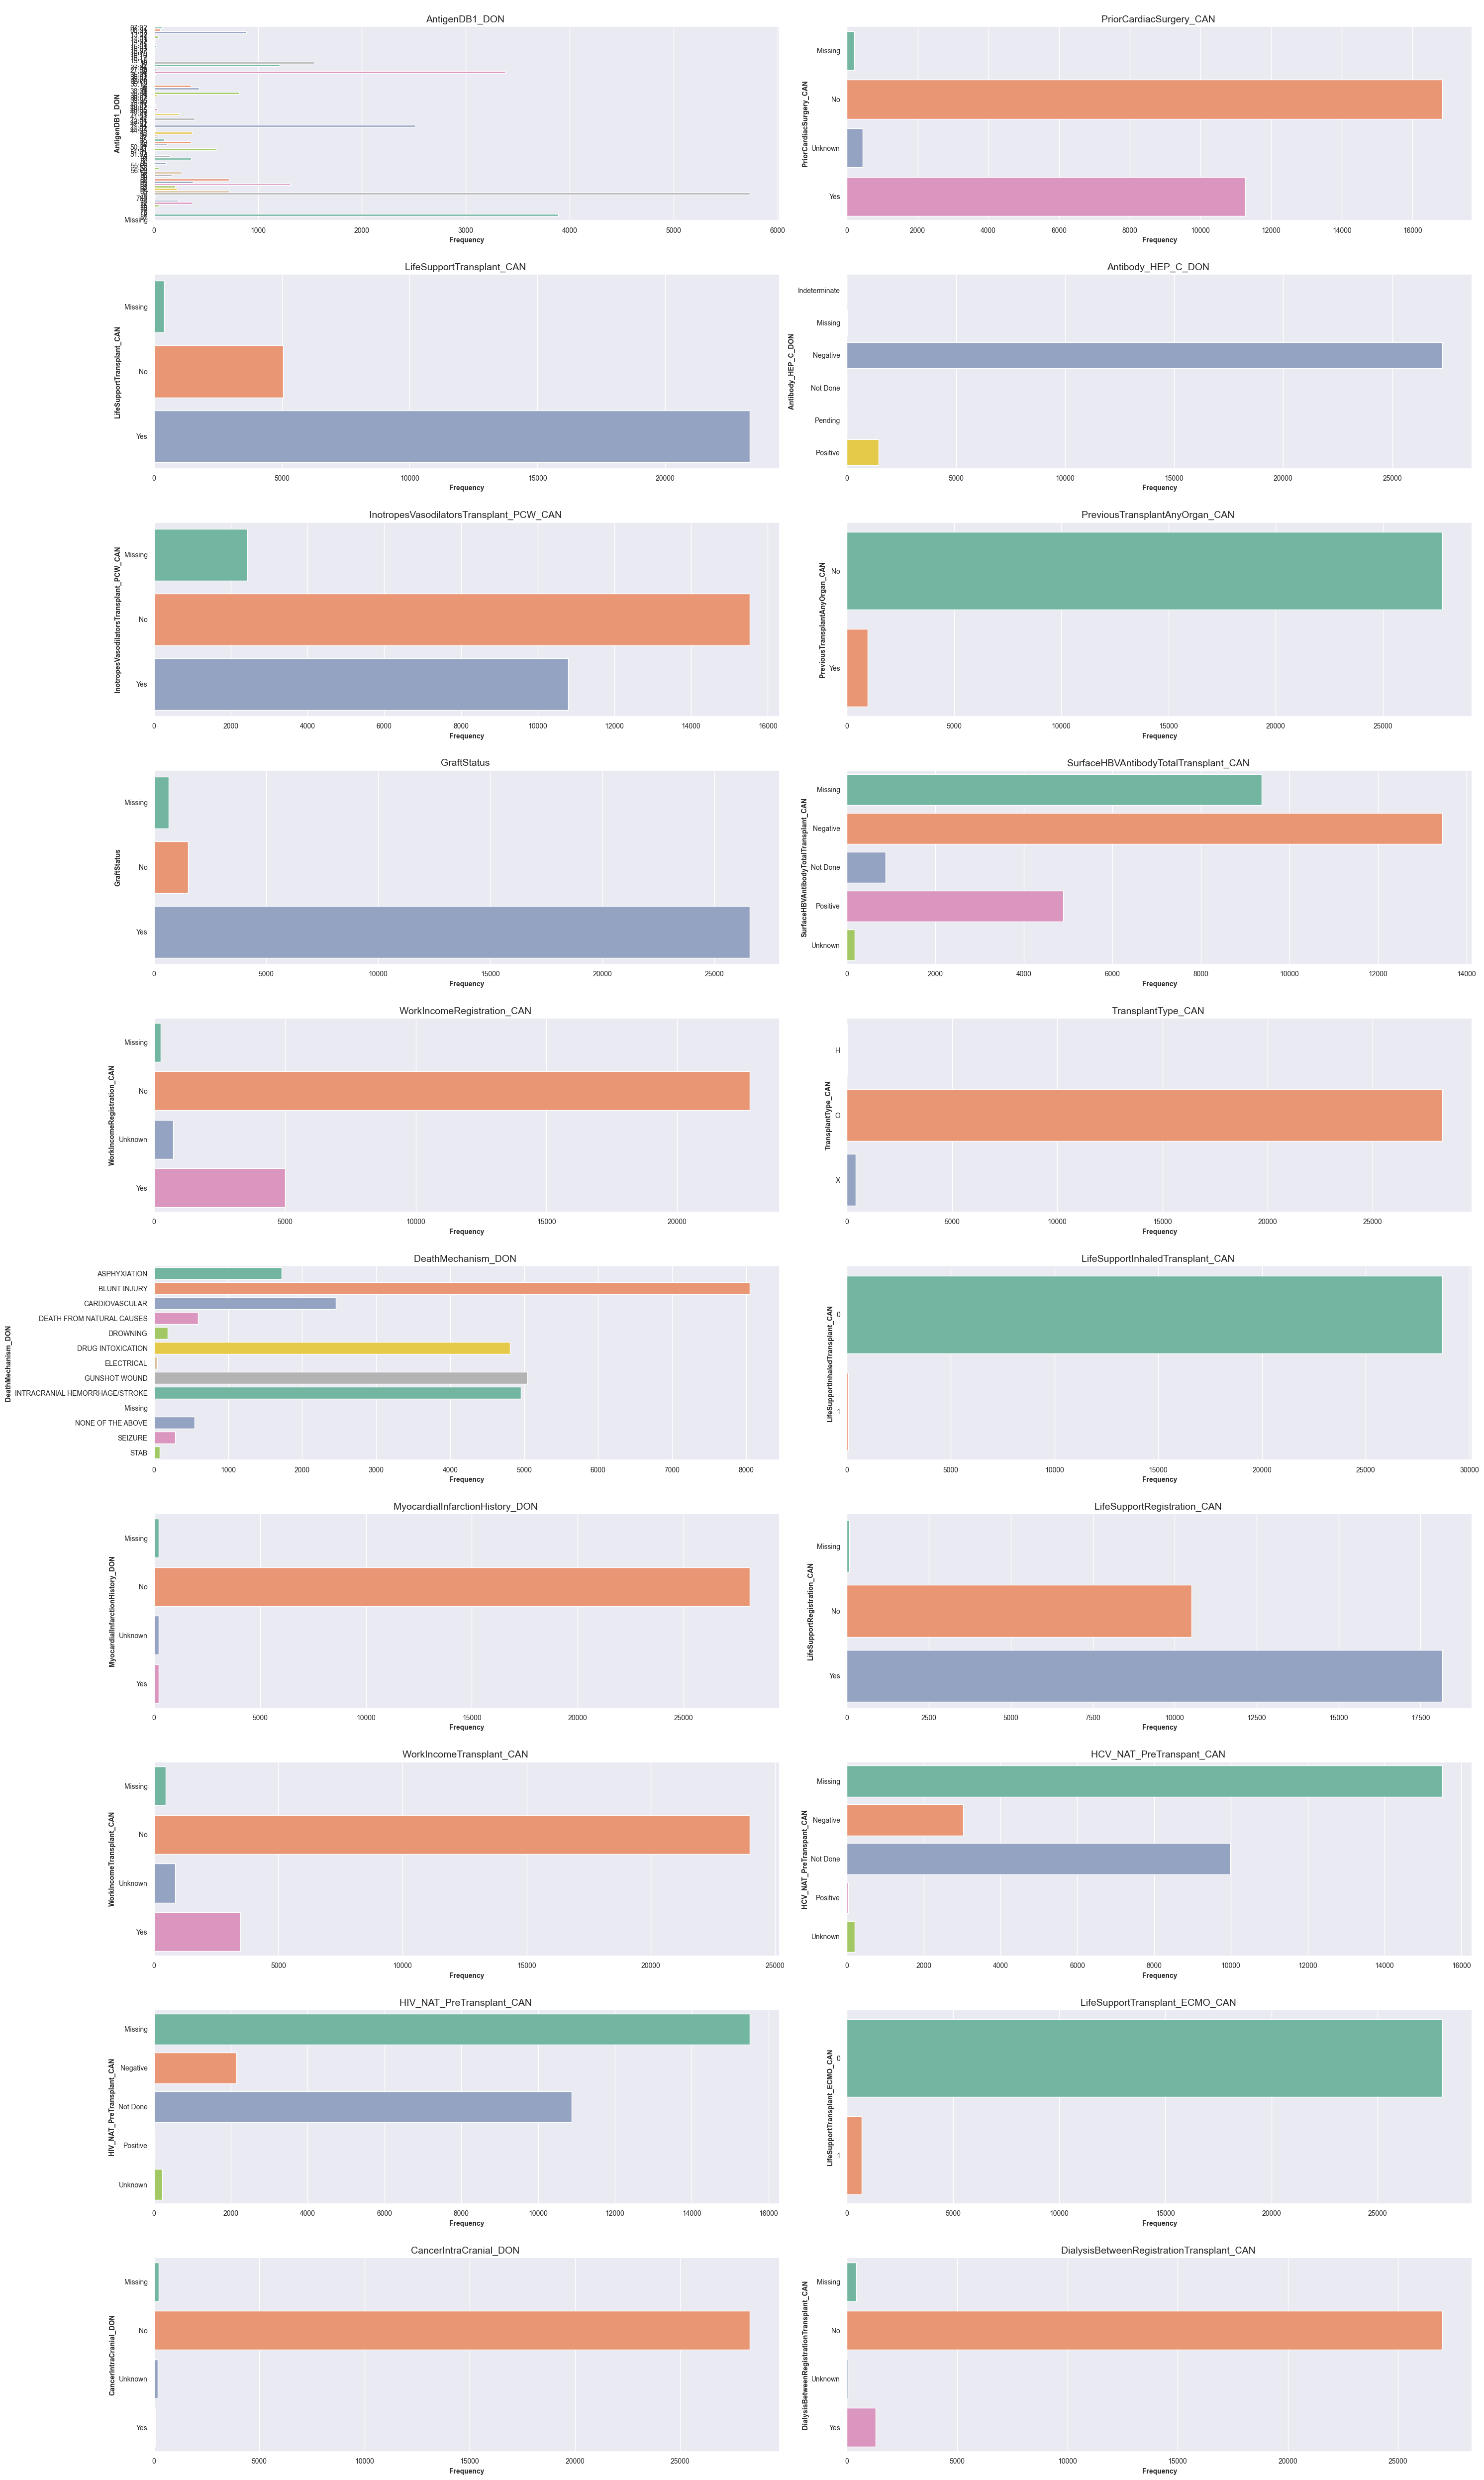

In [41]:
# call the function
uv.plot_categorical_feature_count(df, random_sample, fig_size=(30, 50), tick_font=10, title_font=14)

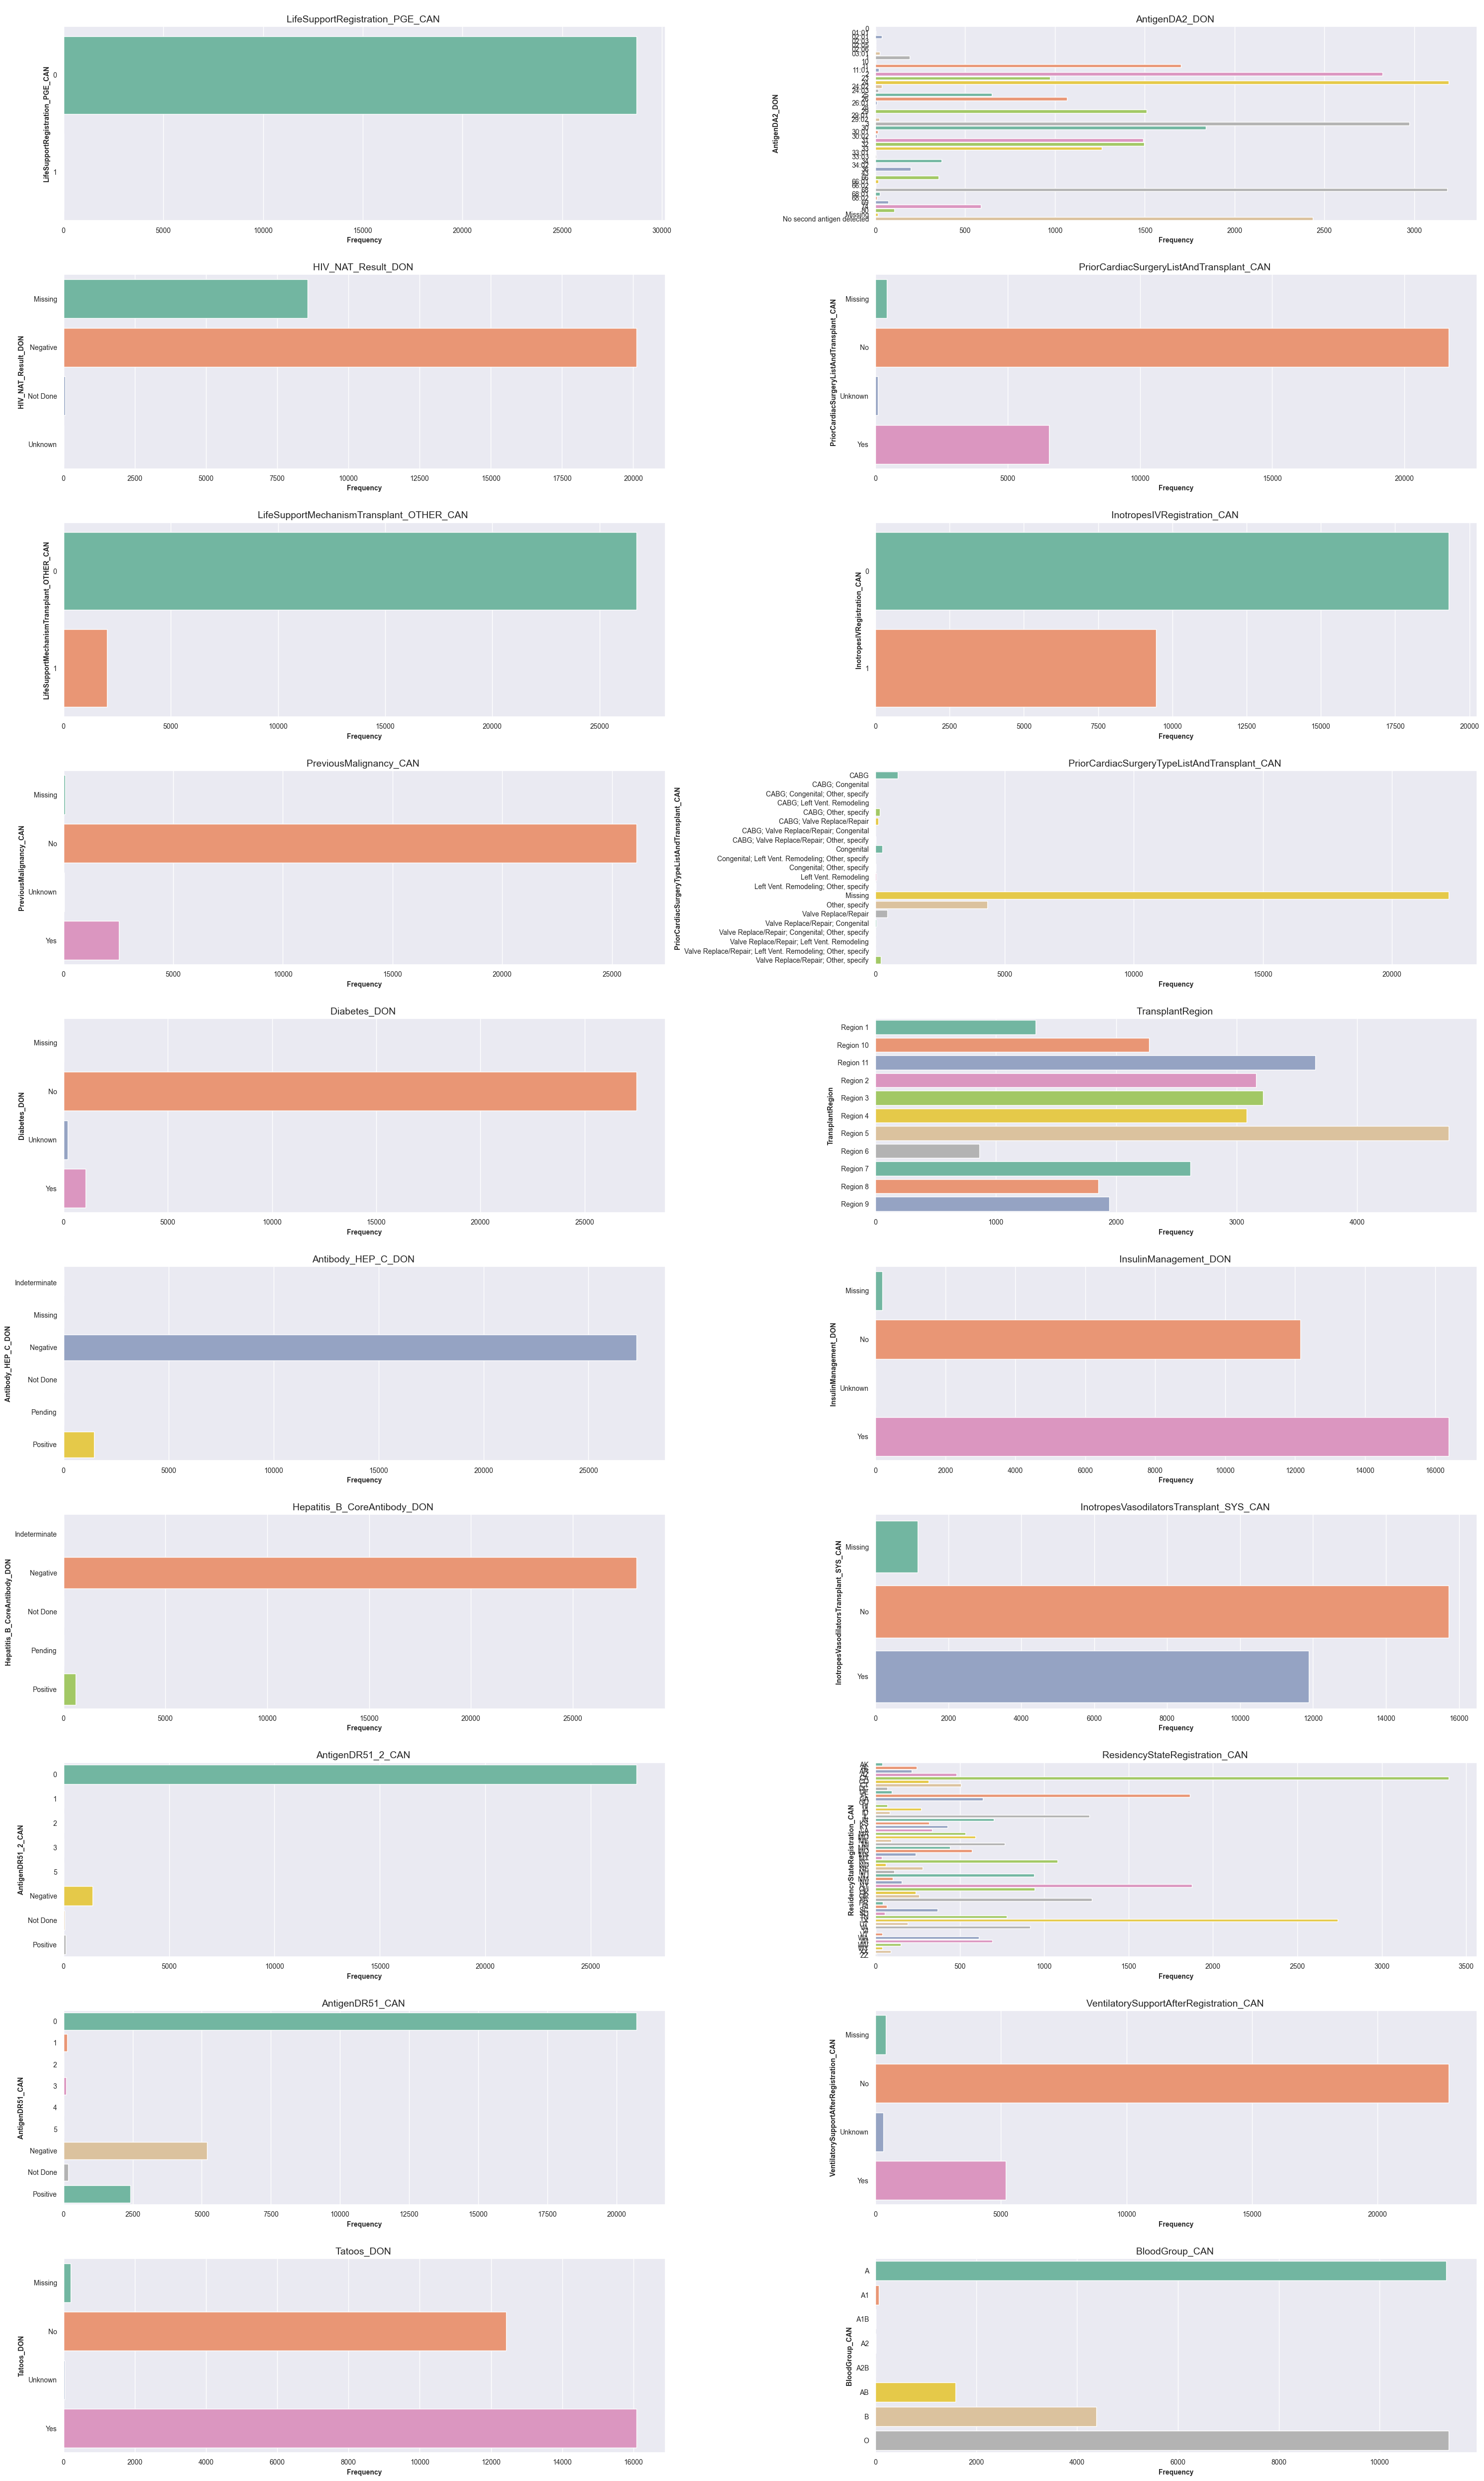

In [42]:
# random 20
random.shuffle(catplot)
random_sample = catplot[:20]

# call the function
uv.plot_categorical_feature_count(df, random_sample, fig_size=(30, 50), tick_font=10, title_font=14)

#### Numeric Plots

In [43]:
# initialize list for plot
numeric = sorted(df_numeric.column.to_list())
# join to concatenate the strings with '|' separator
labelSearch = '|'.join(numeric)
# display search
uf.definition_search(df_dict, labelSearch)

,Feature,Description,DataType,SASAnalysisFormat,Comment,FeatureType,Information
7,Age_CAN,RECIPIENT AGE (YRS),NUM,,,Numeric,
8,Age_DON,DONOR AGE (YRS),NUM,,,Numeric,
16,BMI_DON,Donor BMI - Pre/At Donation Calculated,NUM,,,Numeric,
21,BloodUreaNitrogenLevel_DON,DECEASED DONOR-TERMINAL BLOOD UREA NITROGEN,NUM,,,Numeric,
45,Creatinine_DON,DECEASED DONOR-TERMINAL LAB CREATININE,NUM,,,Numeric,
46,CreatinineTransplant_CAN,RECIPIENT SERUM CREATININE AT TIME OF TX,NUM,,,Numeric,
62,TotalDayWaitList_CAN,TOTAL DAYS ON WAITING LIST,NUM,,,Numeric,
77,DistanceFromDonorHospitaltoTXCenter,DISTANCE FROM DONOR HOSP TO TX CENTER (Nautical Miles),NUM,,,Numeric,** LABEL ** N/Y/U/X to No/Yes/Unknown/Missing
97,BMI_CAN,Calculated Candidate BMI at Removal/Current Time,NUM,,,Numeric,
99,HeightCm_CAN,Calculated Candidate Height in CM at Removal/Current Time,NUM,,,Numeric,


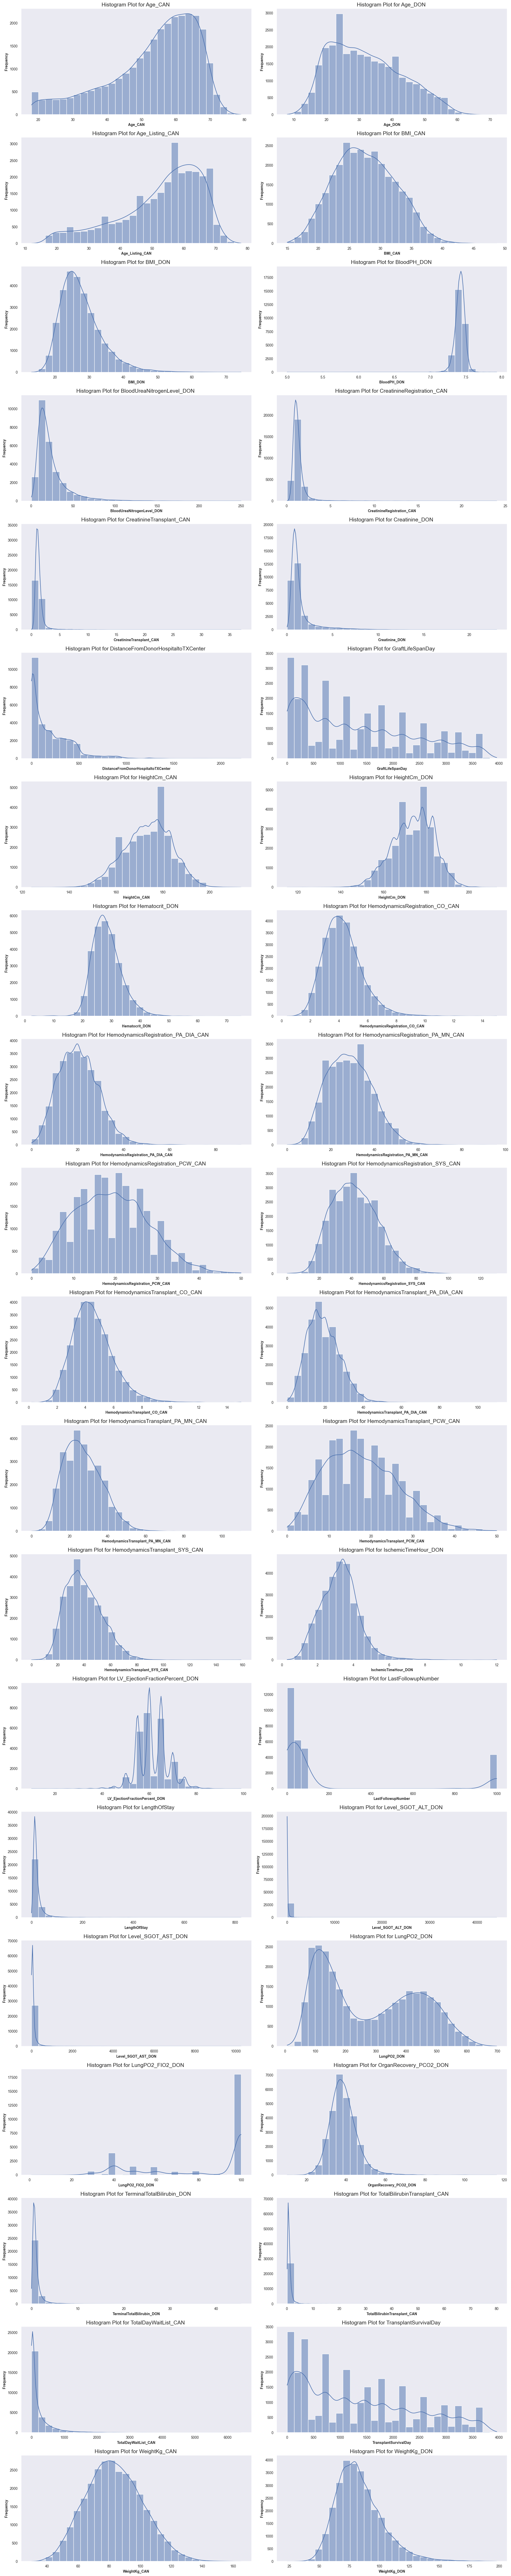

In [44]:
# plot
uv.plot_histogram(df, numeric)

In [45]:
category_contingency(df, 'ListingYear', 'GraftFailStatus')

GraftFailStatus,Failure,Missing,Success,Row Total,Dead %,Living %
ListingYear,,,,,,
1997,1.0,0.0,0.0,1.0,100.000000,0.000000
1998,0.0,0.0,1.0,1.0,0.000000,100.000000
1999,0.0,0.0,1.0,1.0,0.000000,100.000000
2000,0.0,0.0,1.0,1.0,0.000000,100.000000
2001,0.0,0.0,1.0,1.0,0.000000,100.000000
2002,0.0,0.0,2.0,2.0,0.000000,100.000000
2003,1.0,0.0,2.0,3.0,33.333333,66.666667
2004,4.0,0.0,6.0,10.0,40.000000,60.000000
2005,2.0,0.0,6.0,8.0,25.000000,75.000000


In [46]:
category_contingency(df, 'Gender_CAN', 'GraftFailStatus')

GraftFailStatus,Failure,Missing,Success,Row Total,Dead %,Living %
Gender_CAN,,,,,,
F,1547.0,107.0,6042.0,7696.0,20.101351,78.508316
M,4199.0,319.0,16537.0,21055.0,19.943006,78.541914
Column Total,5746.0,426.0,22579.0,28751.0,19.985392,78.532921


#### Multivariate Plots

In [47]:
def plot_box(data, columns, orientation='h', fig_size=(8, 6)):
    """
    Plots boxplots for specified columns in a DataFrame.

    Parameters:
    data (DataFrame): The DataFrame containing the data to plot.
    columns (list): A list of column names to plot.
    orientation (str): Orientation of the boxplots - 'h' for horizontal, 'v' for vertical. Default is 'h'.
    figsize (tuple): Size of the figure as (width, height). Default is (15, 5).

    Returns:
    None
    """
    # Set the figure size
    plt.figure(figsize=fig_size)
    
    # Determine the number of rows needed for subplots
    num_columns = len(columns)
    num_rows = (num_columns + 1) // 2
    
    # Iterate through each specified column and create a boxplot
    for i, column in enumerate(columns, 1):
        plt.subplot(num_rows, 2, i)
        if orientation == 'v':
            sns.boxplot(y=data[column])
        else:
            sns.boxplot(x=data[column])
        plt.title(f'Boxplot of {column}')
        plt.tight_layout()
    
    # Display the plots
    plt.show()


def plot_violin(data, columns, orientation='h', fig_size=(8, 6)):
    """
    Plots violin plots with box plots inside for specified columns in a DataFrame.

    Parameters:
    data (DataFrame): The DataFrame containing the data to plot.
    columns (list): A list of column names to plot.
    orientation (str): Orientation of the violin plots - 'h' for horizontal, 'v' for vertical. Default is 'h'.
    fig_size (tuple): Size of the figure as (width, height). Default is (8, 6).

    Returns:
    None
    """
    # Set the figure size
    plt.figure(figsize=fig_size)
    
    # Determine the number of rows needed for subplots
    num_columns = len(columns)
    num_rows = (num_columns + 1) // 2
    
    # Iterate through each specified column and create a violin plot with box plot inside
    for i, column in enumerate(columns, 1):
        plt.subplot(num_rows, 2, i)
        if orientation == 'v':
            sns.violinplot(y=data[column], inner='box')
        else:
            sns.violinplot(x=data[column], inner='box')
        plt.title(f'Violin Plot of {column}')
        plt.tight_layout()
    
    # Display the plots
    plt.show()


def plot_violin(data, columns, orientation='h', fig_size=(8, 6), box_color='white', box_width=0.15, box_linewidth=2):
    """
    Plots violin plots with overlaid box plots for specified columns in a DataFrame.

    Parameters:
    data (DataFrame): The DataFrame containing the data to plot.
    columns (list): A list of column names to plot.
    orientation (str): Orientation of the violin plots - 'h' for horizontal, 'v' for vertical. Default is 'h'.
    fig_size (tuple): Size of the figure as (width, height). Default is (8, 6).
    box_color (str): Color of the overlaid box plot. Default is 'white'.
    box_width (float): Width of the box plot. Default is 0.15.
    box_linewidth (int): Line width of the box plot. Default is 2.

    Returns:
    None
    """
    plt.figure(figsize=fig_size)
    num_columns = len(columns)
    num_rows = (num_columns + 1) // 2

    for i, column in enumerate(columns, 1):
        plt.subplot(num_rows, 2, i)
        if orientation == 'v':
            sns.violinplot(y=data[column], inner=None, color='skyblue')
            sns.boxplot(y=data[column], 
                        width=box_width, 
                        color=box_color, 
                        boxprops={'zorder': 2, 'facecolor': box_color, 'linewidth': box_linewidth},
                        whiskerprops={'linewidth': box_linewidth},
                        capprops={'linewidth': box_linewidth},
                        medianprops={'color': 'red', 'linewidth': box_linewidth},
                        flierprops={'markerfacecolor': 'red', 'marker': 'o', 'markersize': 6, 'linestyle': 'none'})
        else:
            sns.violinplot(x=data[column], inner=None, color='skyblue')
            sns.boxplot(x=data[column], 
                        width=box_width, 
                        color=box_color, 
                        boxprops={'zorder': 2, 'facecolor': box_color, 'linewidth': box_linewidth},
                        whiskerprops={'linewidth': box_linewidth},
                        capprops={'linewidth': box_linewidth},
                        medianprops={'color': 'red', 'linewidth': box_linewidth},
                        flierprops={'markerfacecolor': 'red', 'marker': 'o', 'markersize': 6, 'linestyle': 'none'})
        plt.title(f'Violin & Box Plot of {column}')
        plt.tight_layout()

    plt.show()


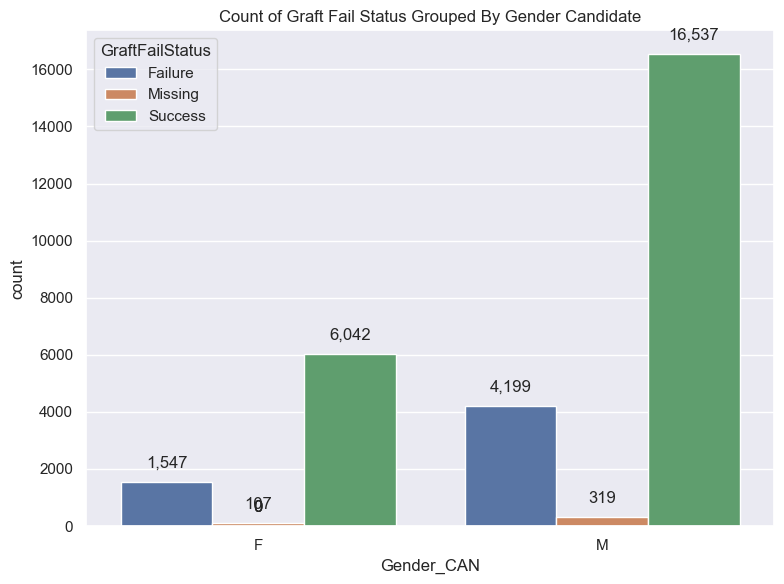

In [48]:
# Create the count plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Gender_CAN', hue='GraftFailStatus')
plt.title('Count of Graft Fail Status Grouped By Gender Candidate')

# Add count labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom',
                xytext=(0, 8),  # approximately 1/2 inch offset in points
                textcoords='offset points')

plt.tight_layout()
plt.show()

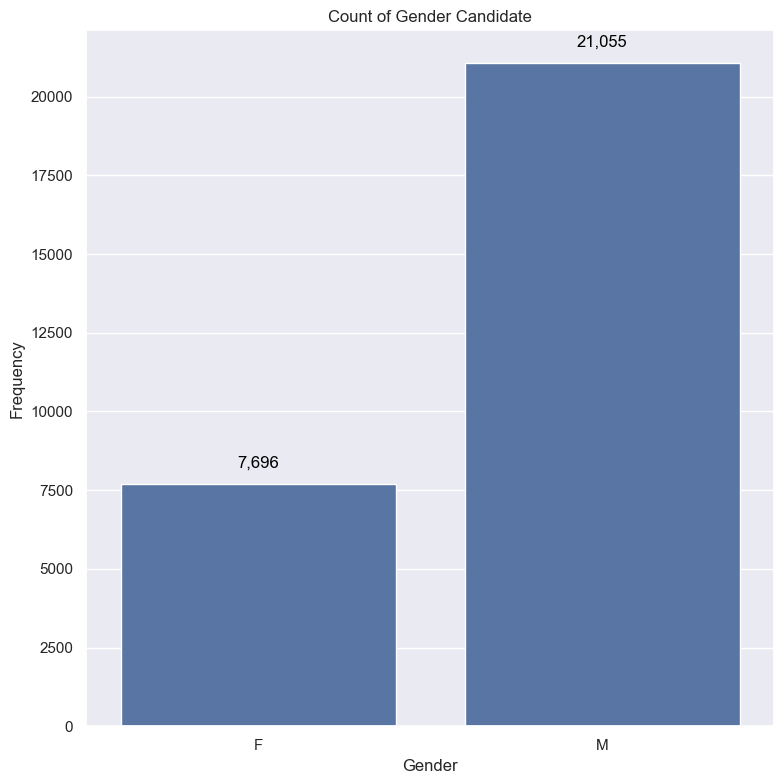

In [49]:
plt.figure(figsize=(8, 8))
ax = sns.countplot(data=df, x='Gender_CAN')
plt.title('Count of Gender Candidate')

# Add count labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 10),
                textcoords='offset points')
plt.ylabel('Frequency')
plt.xlabel('Gender')
plt.tight_layout()
plt.show()

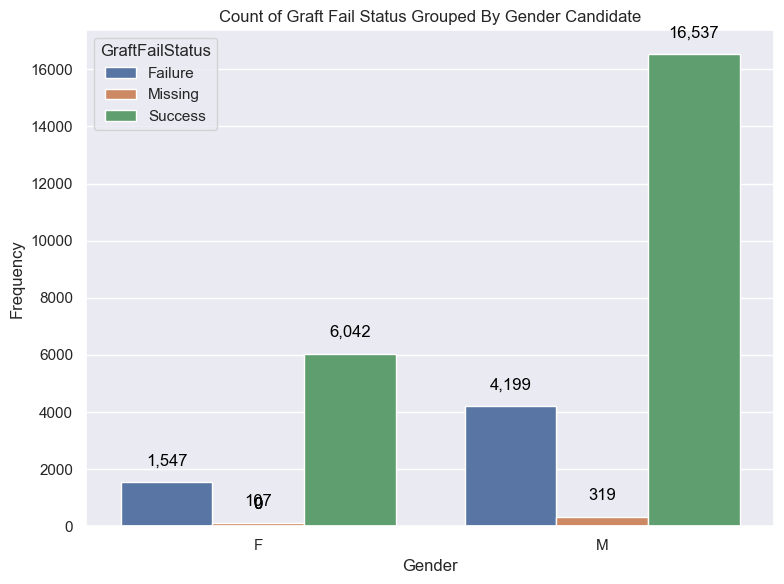

In [50]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Gender_CAN', hue='GraftFailStatus')
plt.title('Count of Graft Fail Status Grouped By Gender Candidate')

# Add count labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 10),
                textcoords='offset points')
plt.ylabel('Frequency')
plt.xlabel('Gender')
plt.tight_layout()
plt.show()

In [51]:
category_contingency(df, 'Gender_CAN', 'GraftFailStatus')

GraftFailStatus,Failure,Missing,Success,Row Total,Dead %,Living %
Gender_CAN,,,,,,
F,1547.0,107.0,6042.0,7696.0,20.101351,78.508316
M,4199.0,319.0,16537.0,21055.0,19.943006,78.541914
Column Total,5746.0,426.0,22579.0,28751.0,19.985392,78.532921


In [52]:
category_contingency(df, 'Ethnicity_DON', 'GraftFailStatus')

GraftFailStatus,Failure,Missing,Success,Row Total,Dead %,Living %
Ethnicity_DON,,,,,,
Amer Ind/Alaska Native,30.0,4.0,139.0,173.0,17.341040,80.346821
Asian,120.0,5.0,387.0,512.0,23.437500,75.585938
Black,1016.0,75.0,3553.0,4644.0,21.877692,76.507321
Hispanic,959.0,91.0,3790.0,4840.0,19.814050,78.305785
Multiracial,47.0,5.0,183.0,235.0,20.000000,77.872340
Native Hawaiian/other Pacific Islander,13.0,1.0,42.0,56.0,23.214286,75.000000
"White, Non-Hispanic",3561.0,245.0,14485.0,18291.0,19.468591,79.191952
Column Total,5746.0,426.0,22579.0,28751.0,19.985392,78.532921


In [53]:
category_contingency(df, 'Ethnicity_DON', 'GraftFailStatus')

GraftFailStatus,Failure,Missing,Success,Row Total,Dead %,Living %
Ethnicity_DON,,,,,,
Amer Ind/Alaska Native,30.0,4.0,139.0,173.0,17.341040,80.346821
Asian,120.0,5.0,387.0,512.0,23.437500,75.585938
Black,1016.0,75.0,3553.0,4644.0,21.877692,76.507321
Hispanic,959.0,91.0,3790.0,4840.0,19.814050,78.305785
Multiracial,47.0,5.0,183.0,235.0,20.000000,77.872340
Native Hawaiian/other Pacific Islander,13.0,1.0,42.0,56.0,23.214286,75.000000
"White, Non-Hispanic",3561.0,245.0,14485.0,18291.0,19.468591,79.191952
Column Total,5746.0,426.0,22579.0,28751.0,19.985392,78.532921


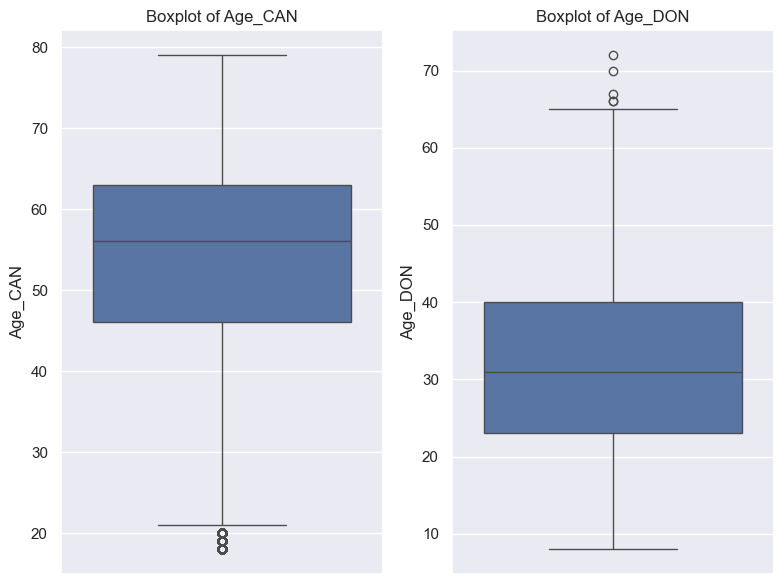

In [54]:
plot_box(df,['Age_CAN', 'Age_DON'],orientation='v')

<Axes: xlabel='Age_CAN', ylabel='GraftFailStatus'>

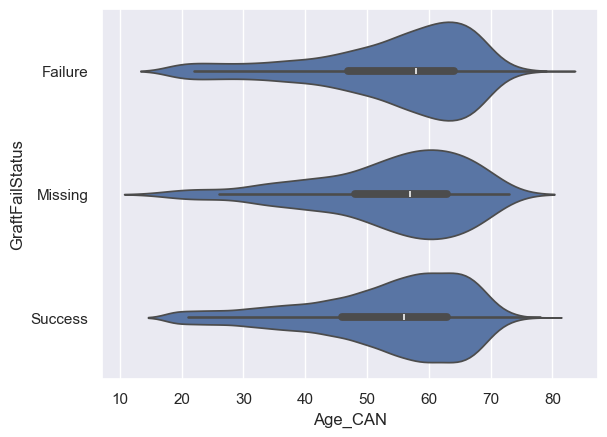

In [55]:
sns.violinplot(data=df, x="Age_CAN", y="GraftFailStatus")

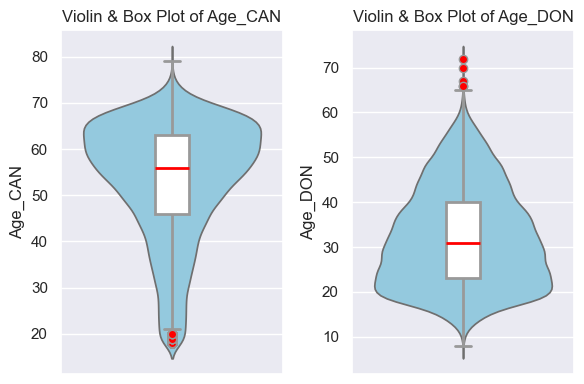

In [56]:
plot_violin(df,['Age_CAN', 'Age_DON'],orientation='v', fig_size=(6, 4))

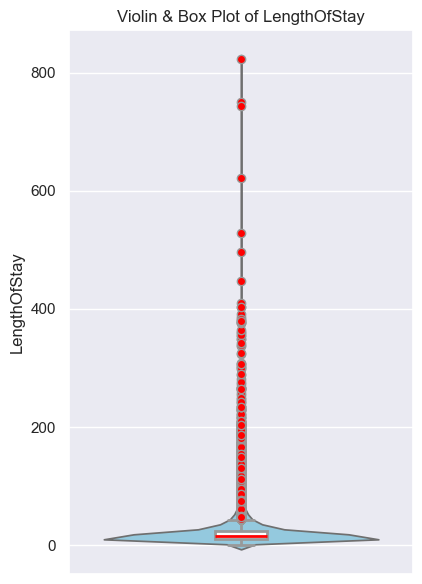

In [57]:
plot_violin(df,['LengthOfStay'],orientation='v', fig_size=(8, 6))

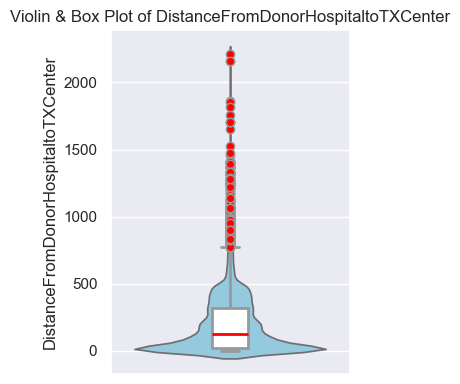

In [58]:
plot_violin(df,['DistanceFromDonorHospitaltoTXCenter'],orientation='v', fig_size=(6, 4))

<Axes: title={'center': 'Histogram Plot of Distance From Donor Hospital To TX Center'}, xlabel='DistanceFromDonorHospitaltoTXCenter', ylabel='Count'>

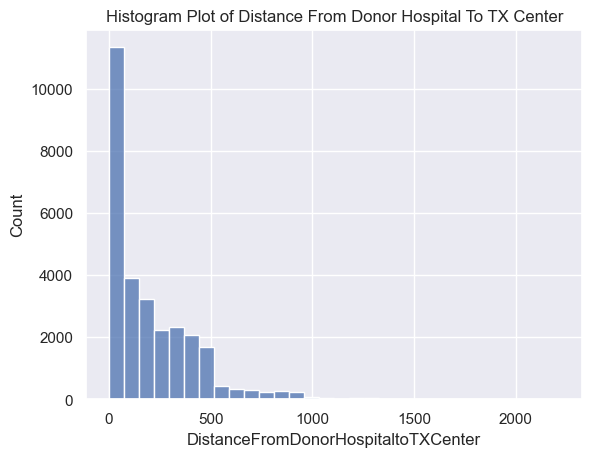

In [59]:
plt.title(f'Histogram Plot of Distance From Donor Hospital To TX Center')
sns.histplot(df, x='DistanceFromDonorHospitaltoTXCenter', bins=30)

<Axes: title={'center': 'Histogram Plot of Ischemic Time Hour(s)'}, xlabel='IschemicTimeHour_DON', ylabel='Count'>

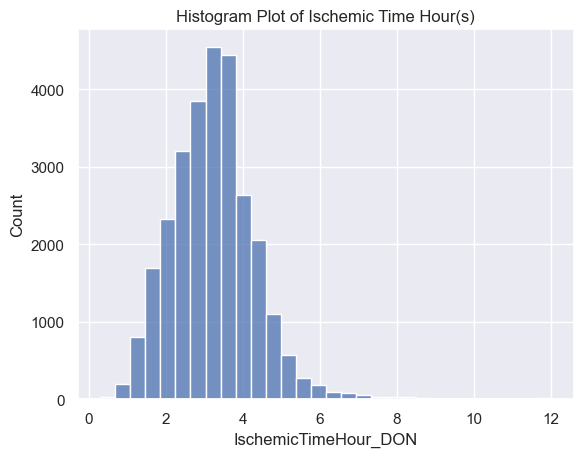

In [60]:
plt.title(f'Histogram Plot of Ischemic Time Hour(s)')
sns.histplot(df, x='IschemicTimeHour_DON', bins=30)

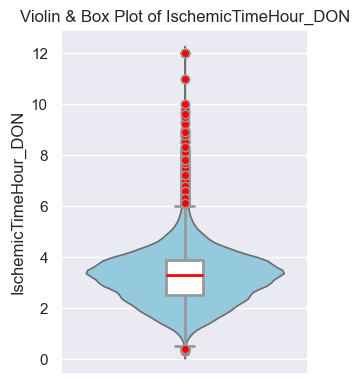

In [61]:
plot_violin(df,['IschemicTimeHour_DON'],orientation='v', fig_size=(6, 4))

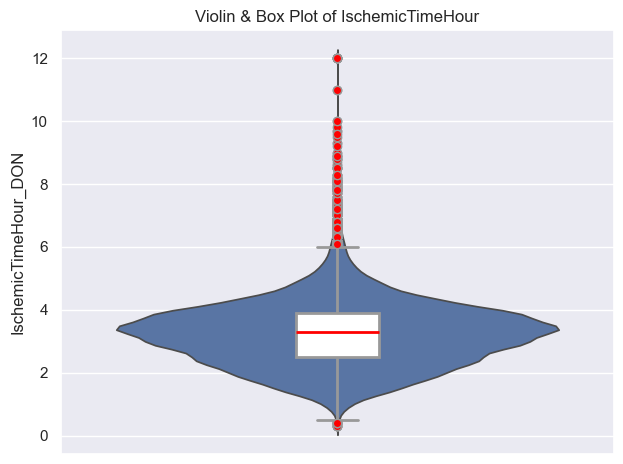

In [62]:
sns.violinplot(y=df['IschemicTimeHour_DON'], inner=None)
sns.boxplot(y=df['IschemicTimeHour_DON'], 
                        width=0.15, 
                        color='white', 
                        boxprops={'zorder': 2, 'facecolor': 'white', 'linewidth': 2},
                        whiskerprops={'linewidth': 2},
                        capprops={'linewidth': 2},
                        medianprops={'color': 'red', 'linewidth': 2},
                        flierprops={'markerfacecolor': 'red', 'marker': 'o', 'markersize': 6, 'linestyle': 'none'})
plt.title(f'Violin & Box Plot of IschemicTimeHour')
plt.tight_layout()
plt.show()

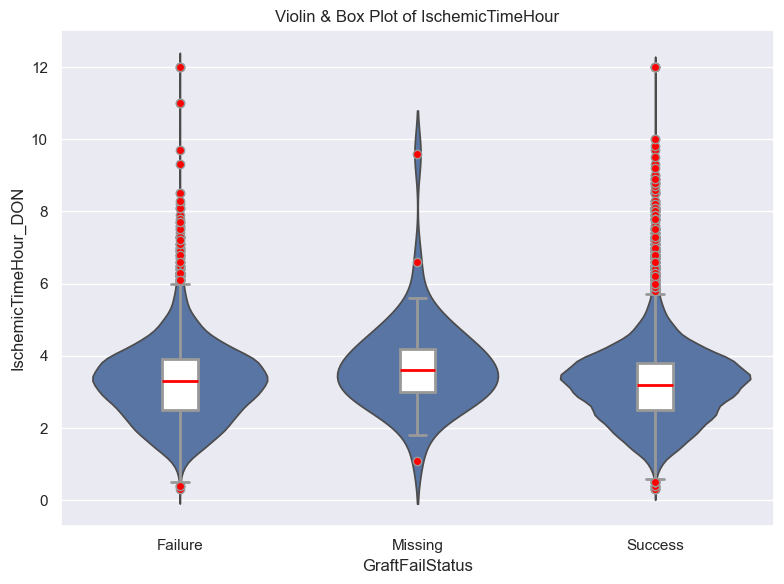

In [63]:
plt.figure(figsize=(8, 6))
sns.violinplot(
    y=df['IschemicTimeHour_DON'],
    x=df['GraftFailStatus'],
    inner=None
)
sns.boxplot(
    y=df['IschemicTimeHour_DON'],
    x=df['GraftFailStatus'],
    width=0.15,
    color='white',
    boxprops={'zorder': 2, 'facecolor': 'white', 'linewidth': 2},
    whiskerprops={'linewidth': 2},
    capprops={'linewidth': 2},
    medianprops={'color': 'red', 'linewidth': 2},
    flierprops={'markerfacecolor': 'red', 'marker': 'o', 'markersize': 6, 'linestyle': 'none'}
)
plt.title('Violin & Box Plot of IschemicTimeHour')
plt.tight_layout()
plt.show()


In [64]:
contingency_table = category_contingency(df, 'IschemicTimeHour_DON', 'GraftFailStatus')

In [65]:
dfi.export(contingency_table, 'contingency_table.png', table_conversion='matplotlib')

In [66]:
contingency_table.head()

GraftFailStatus,Failure,Missing,Success,Row Total,Dead %,Living %
IschemicTimeHour_DON,,,,,,
0.3,1.0,0.0,4.0,5.0,20.000000,80.000000
0.4,3.0,0.0,4.0,7.0,42.857143,57.142857
0.5,2.0,0.0,7.0,9.0,22.222222,77.777778
0.6,0.0,0.0,4.0,4.0,0.000000,100.000000
0.7,3.0,0.0,17.0,20.0,15.000000,85.000000


In [67]:
pd.crosstab(df['IschemicTimeHour_DON'], df['GraftFailStatus'])

GraftFailStatus,Failure,Missing,Success
IschemicTimeHour_DON,,,
0.3,1,0,4
0.4,3,0,4
0.5,2,0,7
0.6,0,0,4
0.7,3,0,17
0.8,4,0,32
0.9,14,0,40
1.0,10,0,71
1.1,20,1,98


In [68]:
contingency_table

GraftFailStatus,Failure,Missing,Success,Row Total,Dead %,Living %
IschemicTimeHour_DON,,,,,,
0.3,1.0,0.0,4.0,5.0,20.000000,80.000000
0.4,3.0,0.0,4.0,7.0,42.857143,57.142857
0.5,2.0,0.0,7.0,9.0,22.222222,77.777778
0.6,0.0,0.0,4.0,4.0,0.000000,100.000000
0.7,3.0,0.0,17.0,20.0,15.000000,85.000000
0.8,4.0,0.0,32.0,36.0,11.111111,88.888889
0.9,14.0,0.0,40.0,54.0,25.925926,74.074074
1.0,10.0,0.0,71.0,81.0,12.345679,87.654321
1.1,20.0,1.0,98.0,119.0,16.806723,82.352941


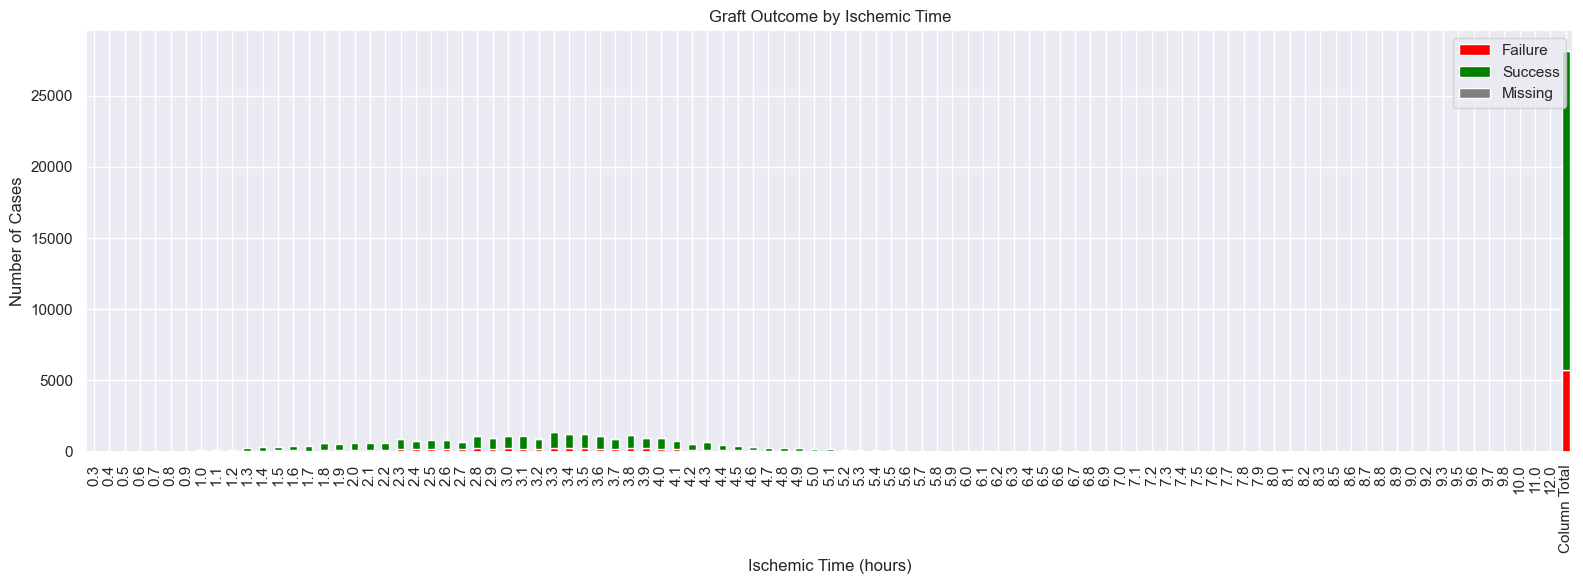

In [69]:
# Set the index if not already
# contingency_table.set_index('IschemicTimeHour_DON', inplace=True)

# Plot
contingency_table[['Failure', 'Success', 'Missing']].plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    color=['red', 'green', 'gray']
)
plt.xlabel('Ischemic Time (hours)')
plt.ylabel('Number of Cases')
plt.title('Graft Outcome by Ischemic Time')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [70]:
print(sorted(df.columns.to_list()))

['AcuteRejectionEpisode', 'Age_CAN', 'Age_DON', 'Age_Listing_CAN', 'AirwayDehiscencePostTransplant', 'AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'ArginnieManagement_DON', 'BMI_CAN', 'BMI_DON', 'Biopsy_DON', 'BloodGroupMatchLevel', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CMVStatus_Transplant_CAN', 'CMV_IGG_Transplant_CAN', 'CMV_IGM_Transplant_CAN', 'Cance

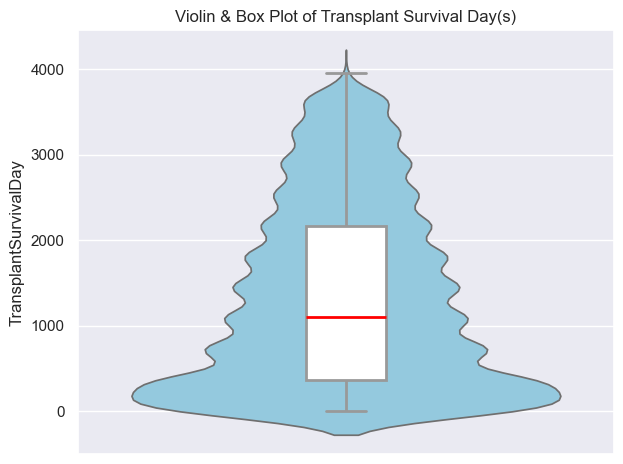

In [71]:
sns.violinplot(y=df['TransplantSurvivalDay'], inner=None, color='skyblue')
sns.boxplot(y=df['TransplantSurvivalDay'], 
                        width=0.15, 
                        color='white', 
                        boxprops={'zorder': 2, 'facecolor': 'white', 'linewidth': 2},
                        whiskerprops={'linewidth': 2},
                        capprops={'linewidth': 2},
                        medianprops={'color': 'red', 'linewidth': 2},
                        flierprops={'markerfacecolor': 'red', 'marker': 'o', 'markersize': 6, 'linestyle': 'none'})
plt.title(f'Violin & Box Plot of Transplant Survival Day(s)')
plt.tight_layout()
plt.show()

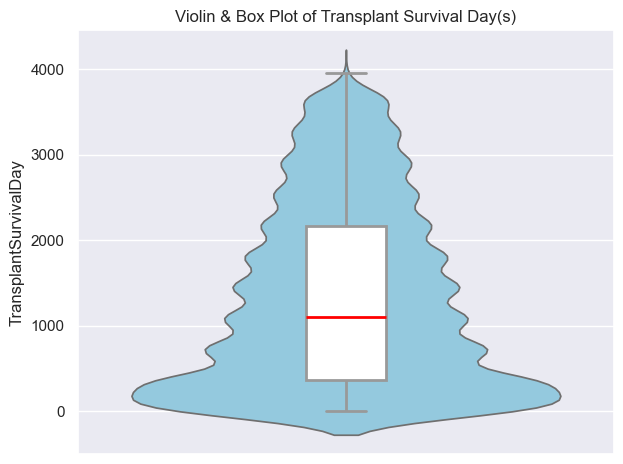

In [72]:
sns.violinplot(y=df['TransplantSurvivalDay'], inner=None, color='skyblue')
sns.boxplot(y=df['TransplantSurvivalDay'], 
                        width=0.15, 
                        color='white', 
                        boxprops={'zorder': 2, 'facecolor': 'white', 'linewidth': 2},
                        whiskerprops={'linewidth': 2},
                        capprops={'linewidth': 2},
                        medianprops={'color': 'red', 'linewidth': 2},
                        flierprops={'markerfacecolor': 'red', 'marker': 'o', 'markersize': 6, 'linestyle': 'none'})
plt.title(f'Violin & Box Plot of Transplant Survival Day(s)')
plt.tight_layout()
plt.show()

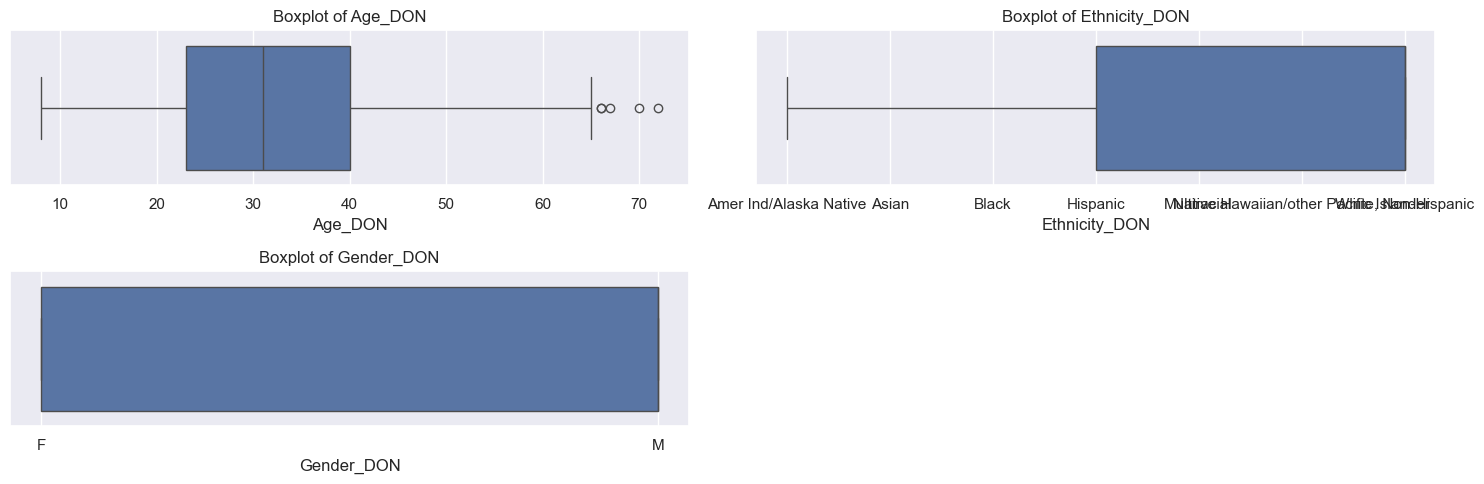

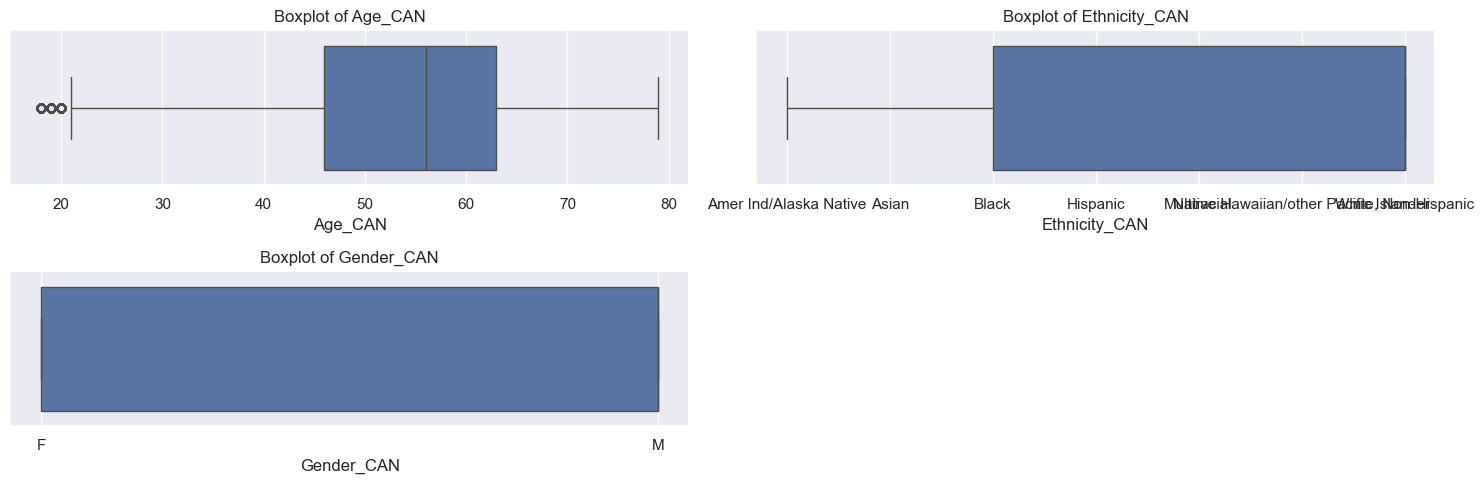

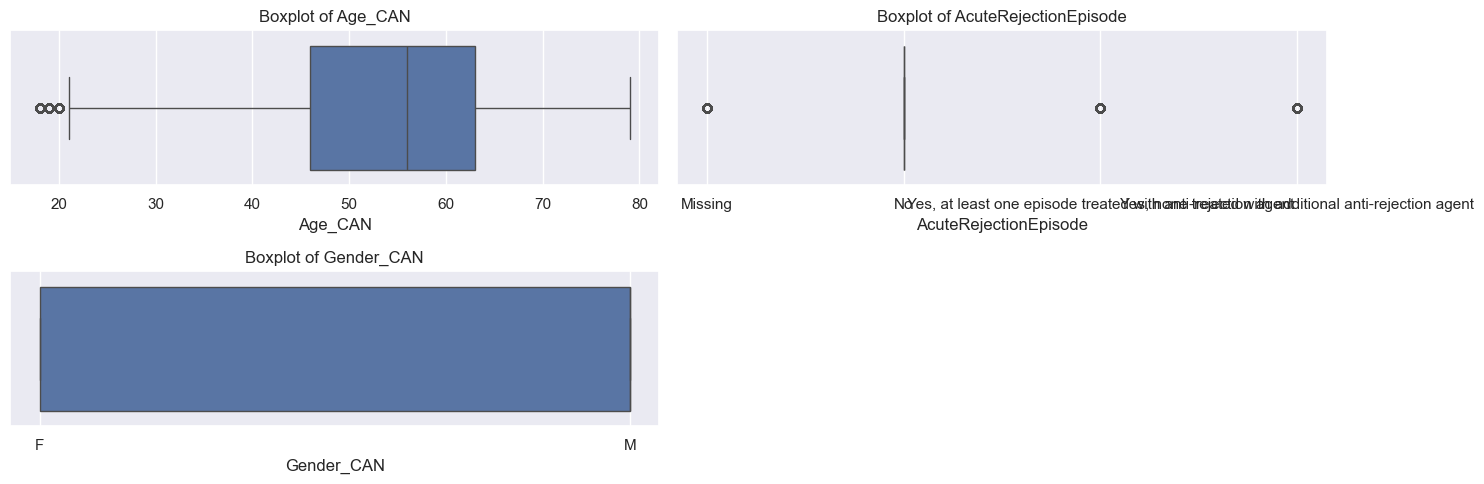

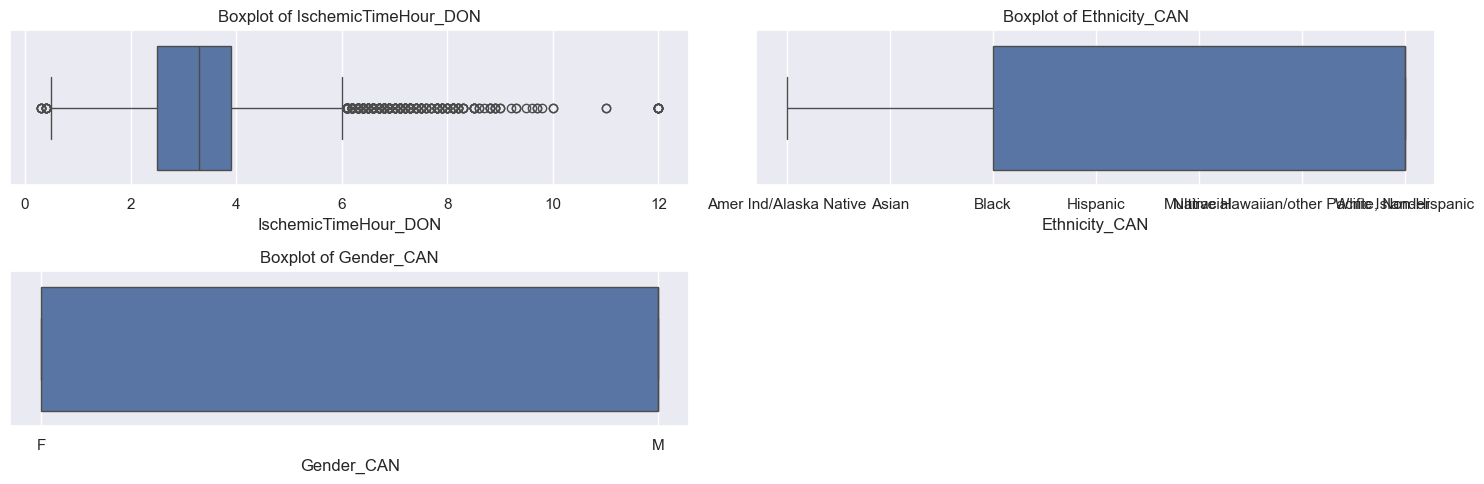

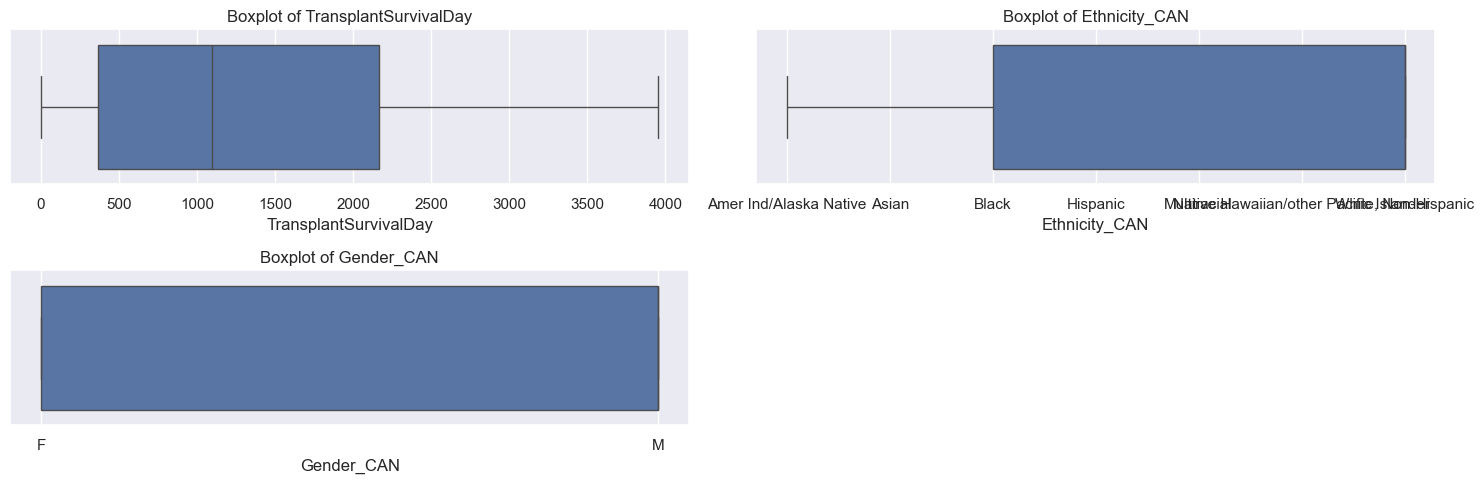

In [73]:
# boxplots
uv.plot_box(df,['Age_DON', 'Ethnicity_DON','Gender_DON'])
uv.plot_box(df,['Age_CAN', 'Ethnicity_CAN','Gender_CAN'])
uv.plot_box(df,['Age_CAN', 'AcuteRejectionEpisode','Gender_CAN'])
uv.plot_box(df,['IschemicTimeHour_DON', 'Ethnicity_CAN','Gender_CAN'])
uv.plot_box(df,['TransplantSurvivalDay', 'Ethnicity_CAN','Gender_CAN'])

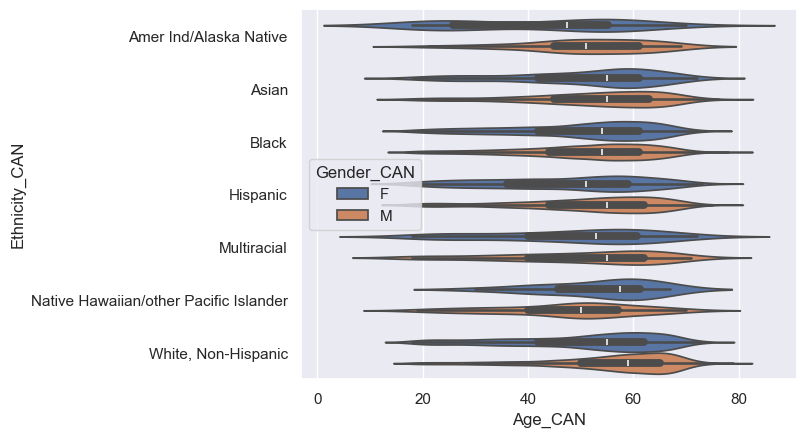

In [74]:
sns.violinplot(df, x='Age_CAN', y='Ethnicity_CAN',hue='Gender_CAN');

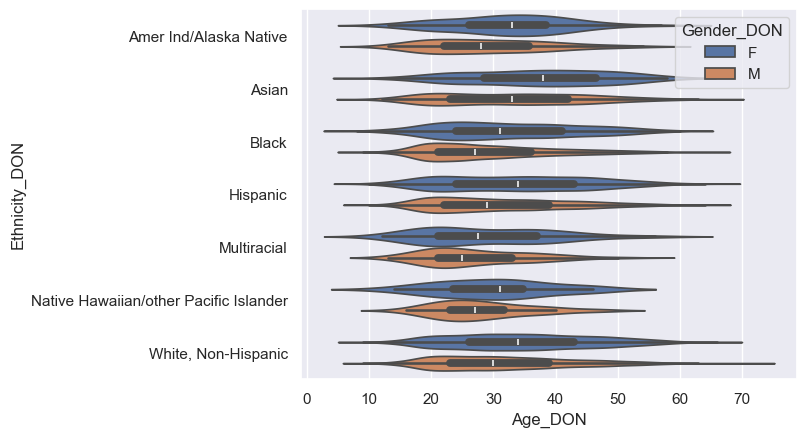

In [75]:
sns.violinplot(df, x='Age_DON', y='Ethnicity_DON',hue='Gender_DON');

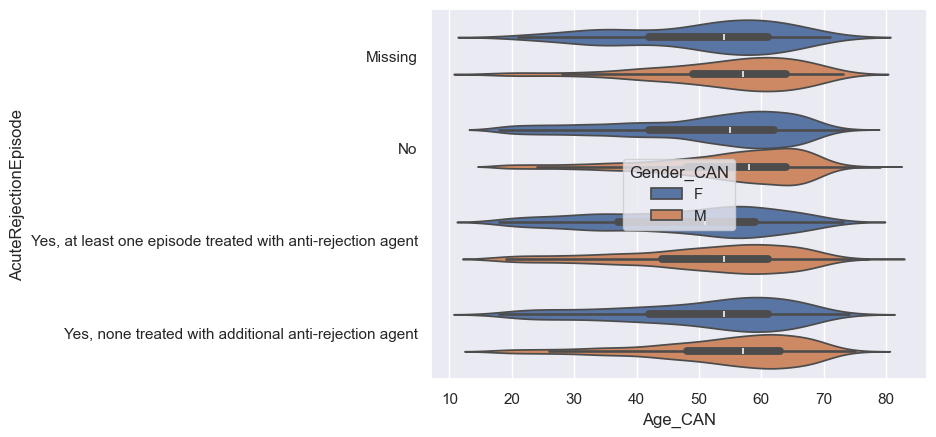

In [76]:
sns.violinplot(df, x='Age_CAN', y='AcuteRejectionEpisode',hue='Gender_CAN');

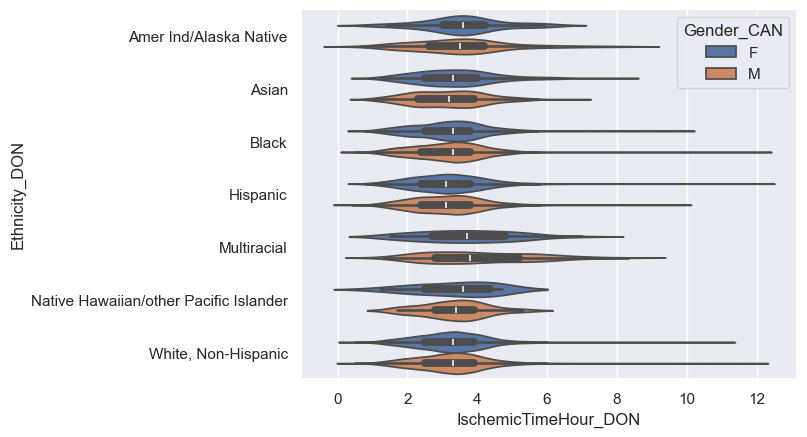

In [77]:
sns.violinplot(df, x='IschemicTimeHour_DON', y='Ethnicity_DON',hue='Gender_CAN');

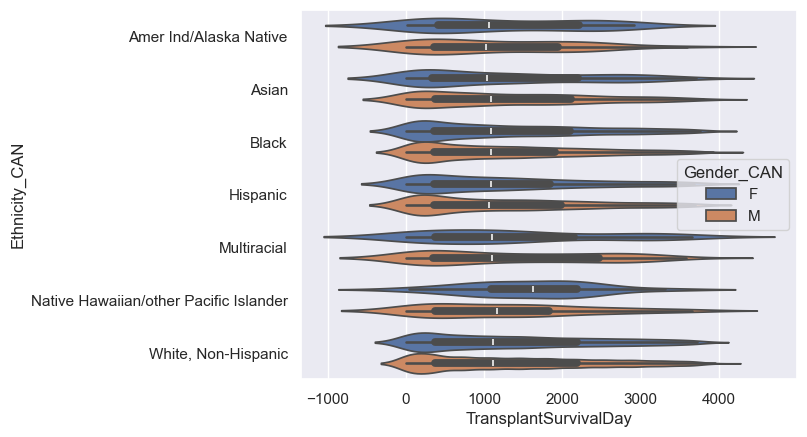

In [78]:
sns.violinplot(df, x='TransplantSurvivalDay', y='Ethnicity_CAN',hue='Gender_CAN');

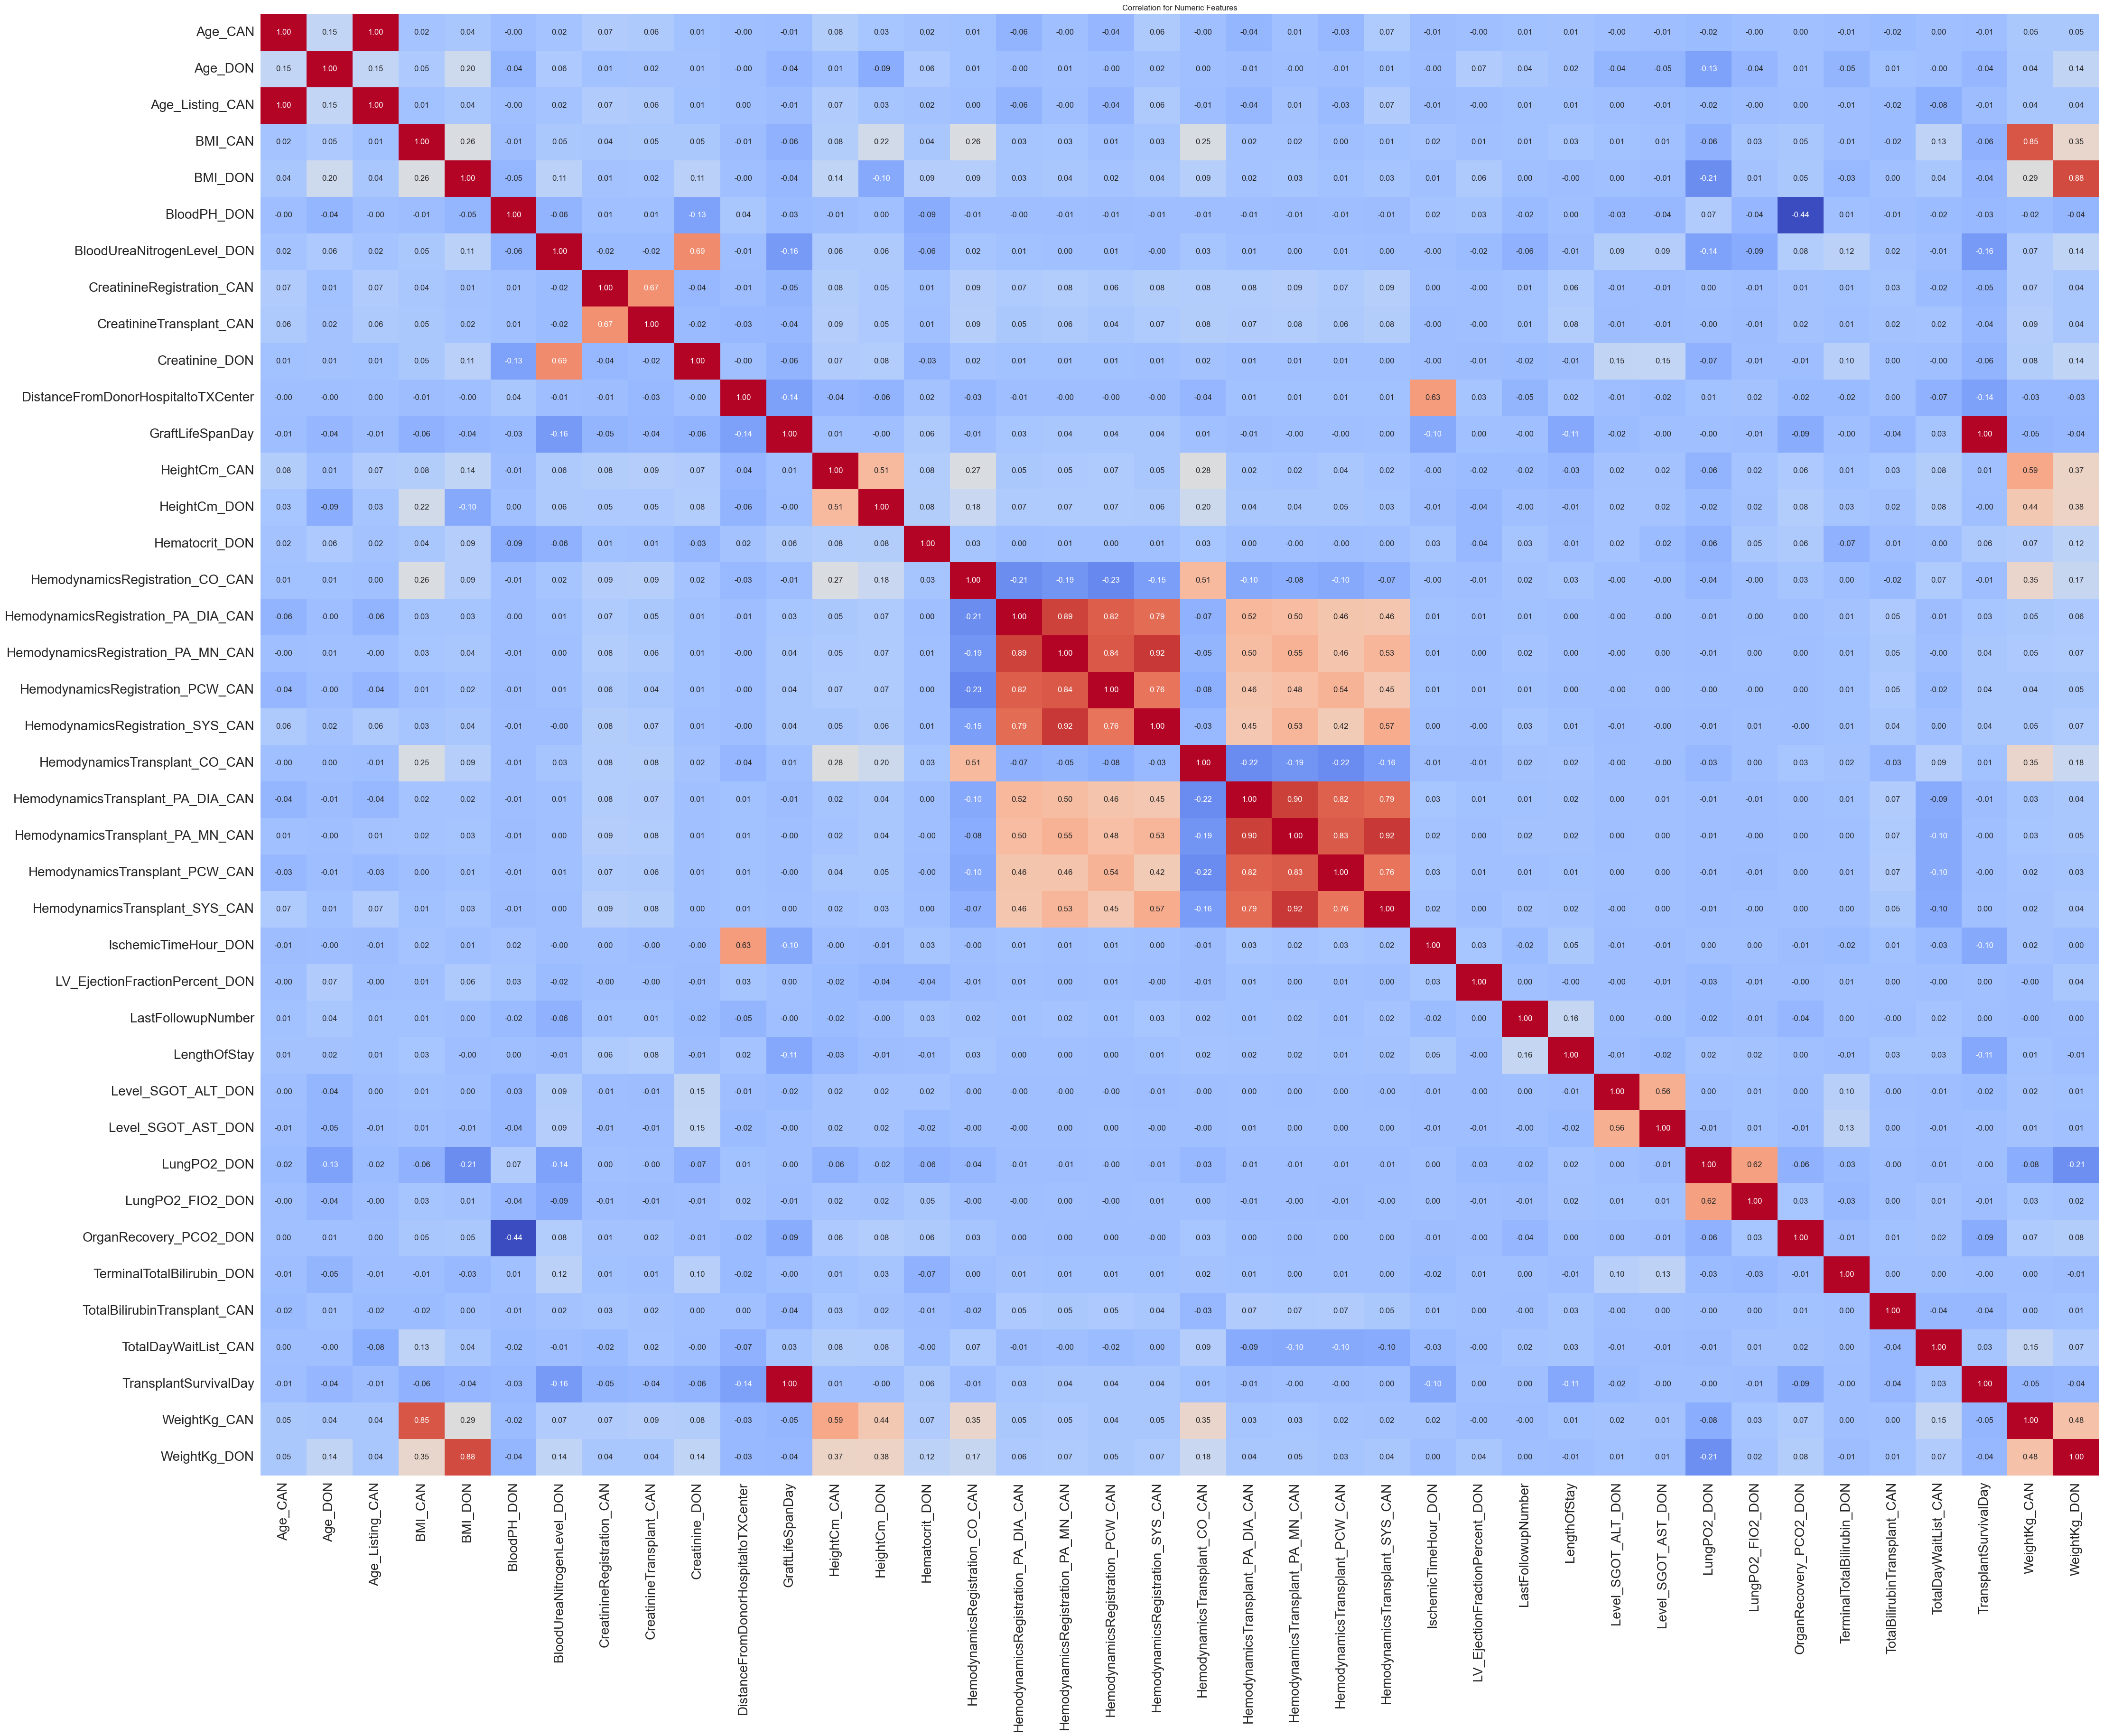

In [79]:
plt.figure(figsize=(50,40))
sns.heatmap(df[numeric].corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title("Correlation for Numeric Features")
# Adjust the font size of the ticks
plt.xticks(fontsize=20)  # font size for x-ticks
plt.yticks(fontsize=20)  # font size for y-ticks
plt.show()

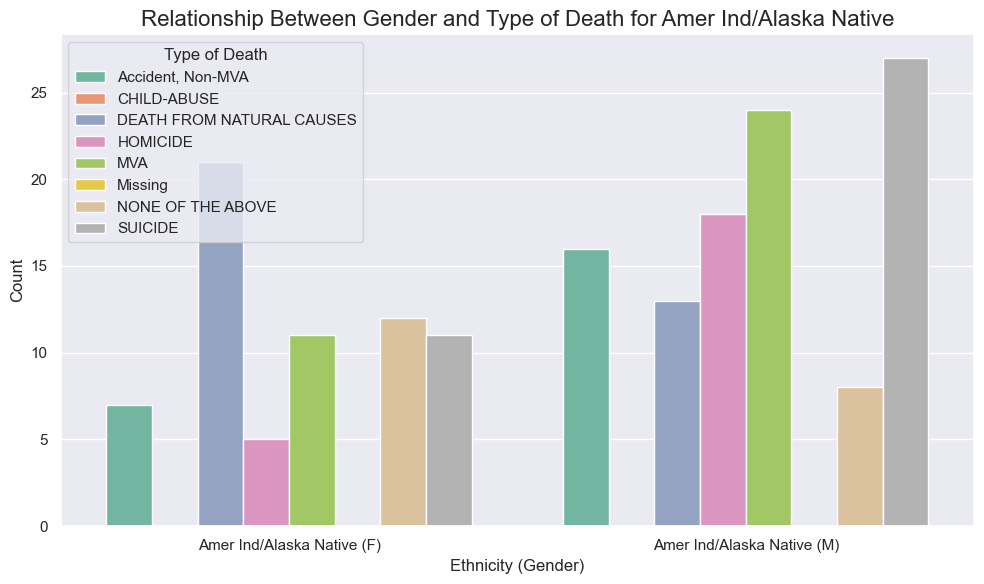

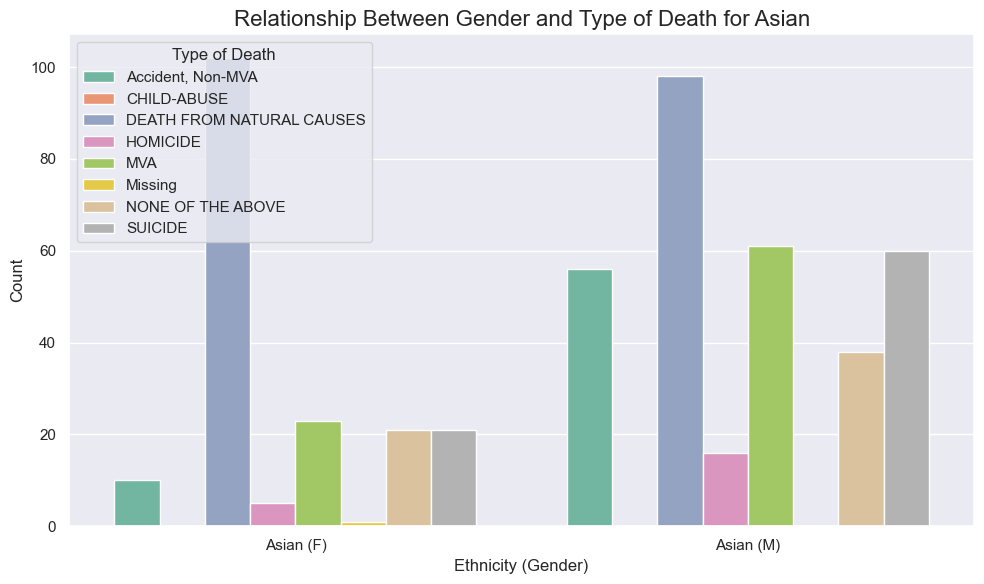

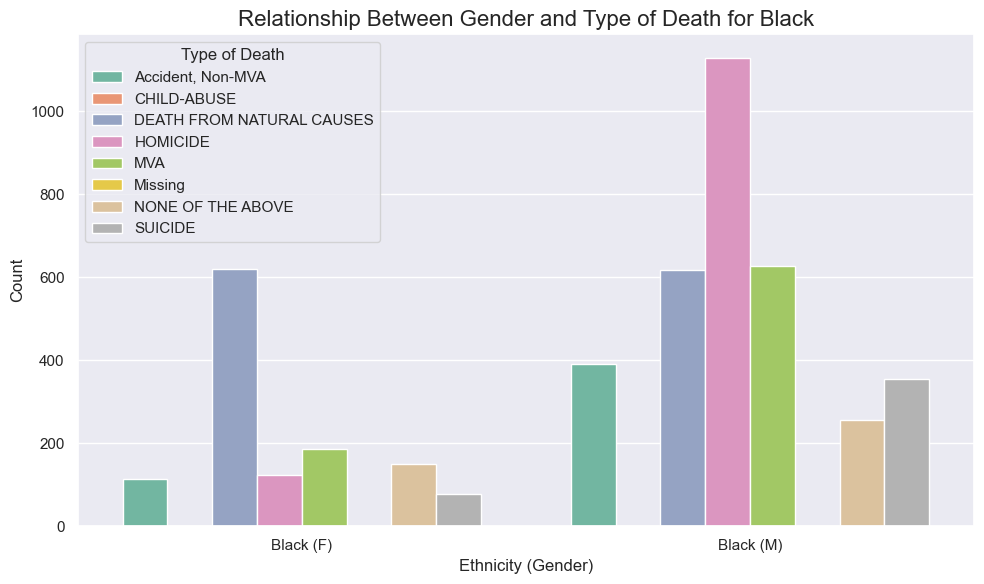

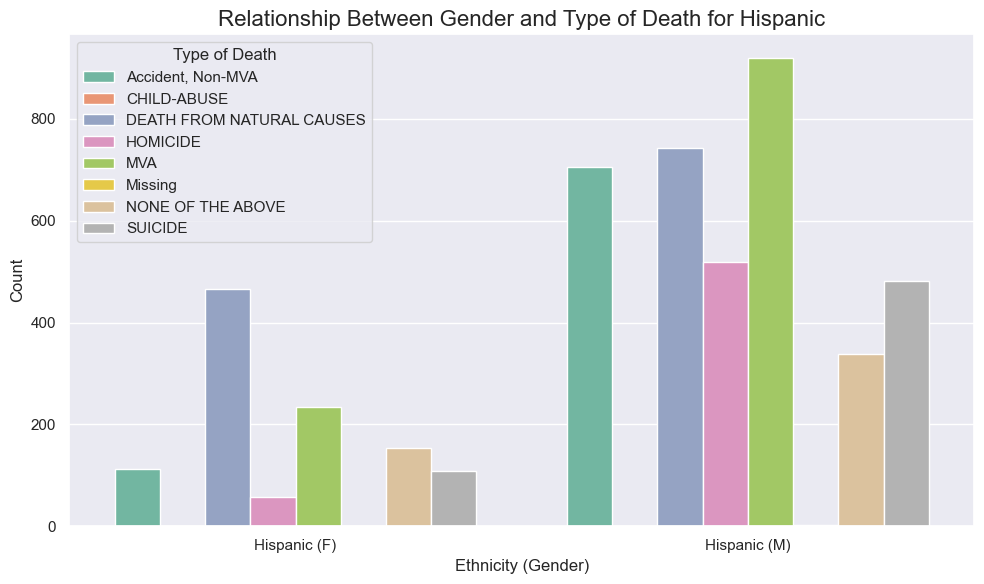

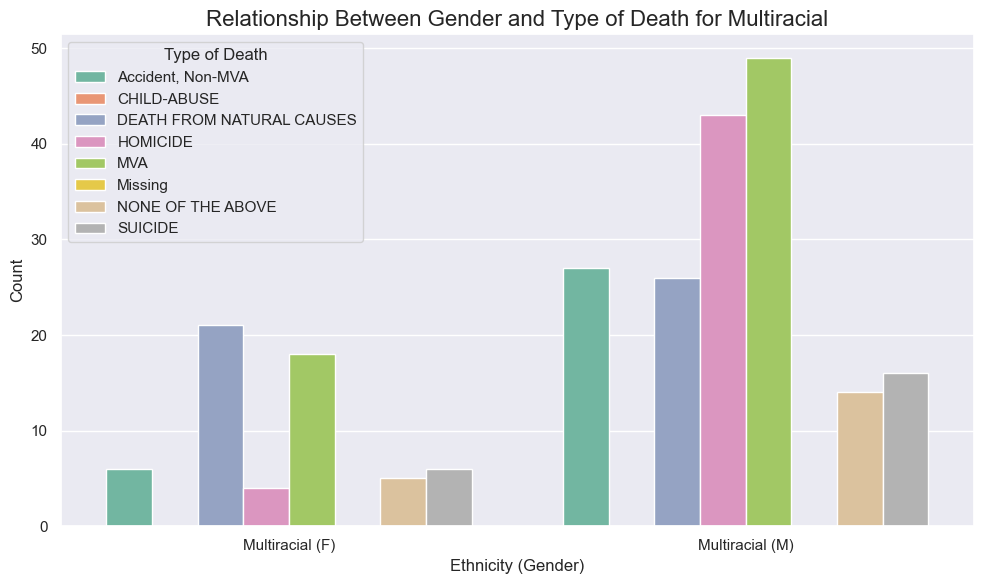

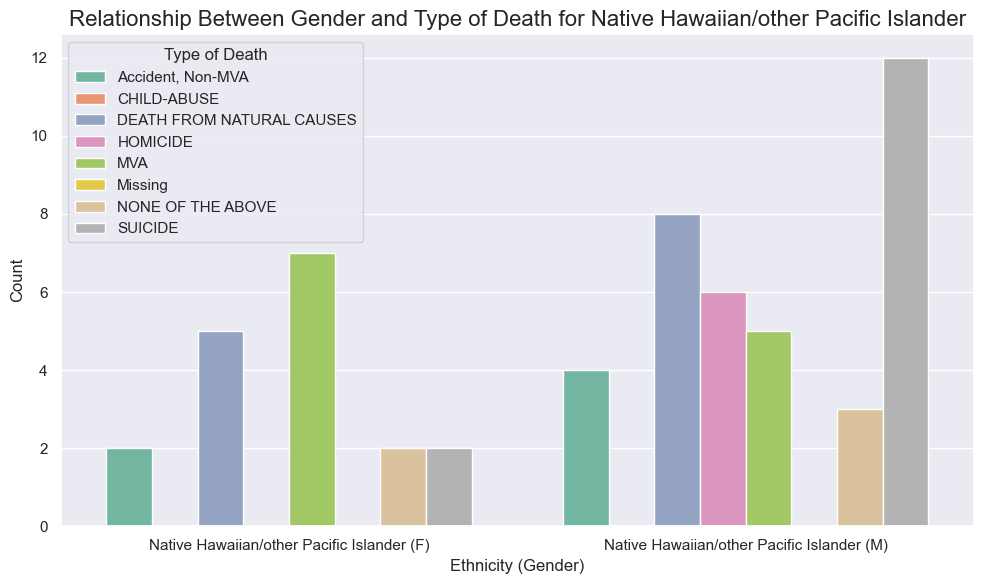

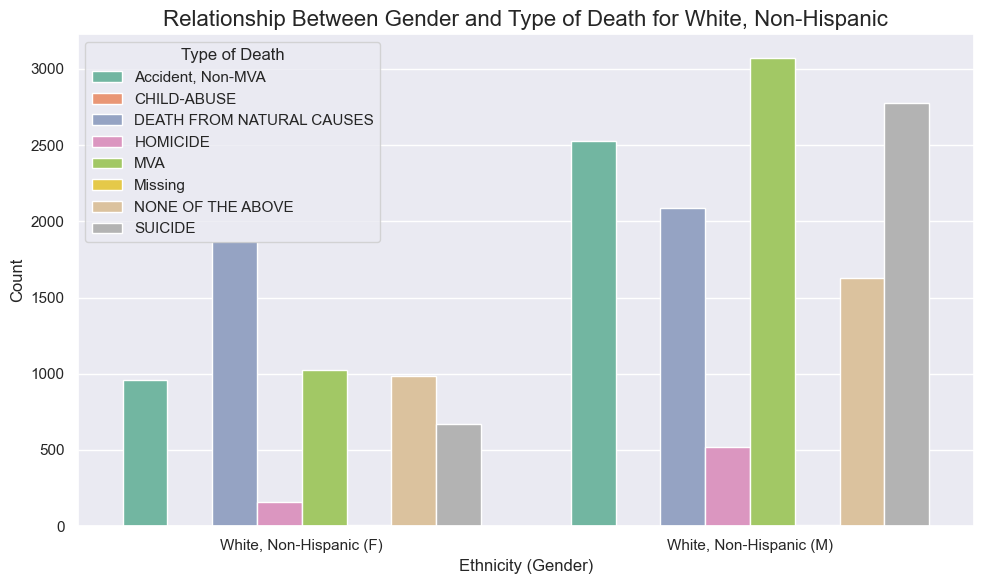

In [80]:
# count occurrences
race_death_counts = df.groupby(['Ethnicity_DON', 'DeathCircumstance_DON', 'Gender_DON'], observed=False).size().reset_index(name='Count')

# ensure columns are strings before concatenation
race_death_counts['Ethnicity_Gender'] = race_death_counts['Ethnicity_DON'].astype(str) + ' (' + race_death_counts['Gender_DON'].astype(str) + ')'

# iterate unique values in Ethnicity_DON
unique_ethnicities = race_death_counts['Ethnicity_DON'].unique()

for ethnicity in unique_ethnicities:
    # filter data for the current ethnicity
    ethnicity_data = race_death_counts[race_death_counts['Ethnicity_DON'] == ethnicity]
    
    # create a barplot for the current ethnicity
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=ethnicity_data,
        x='Ethnicity_Gender',  # Use concatenated column
        y='Count',
        hue='DeathCircumstance_DON',
        errorbar=None,  # Replace ci=None
        dodge=True,
        palette='Set2'
    )
    
    # customize the plot
    plt.title(f"Relationship Between Gender and Type of Death for {ethnicity}", fontsize=16)
    plt.xlabel("Ethnicity (Gender)", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.legend(title="Type of Death", loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
